# DeepSeek-V3 MoE Kernel DAG — B200 GPU

Visualization of the computational DAG from `kernel_ref.py`.

**Legend:**
- Green = graph input | Yellow = graph output | Blue = intermediate
- Op boxes color-coded by phase
- Dimensions use: T=tokens, H=7168, I=2048, E_local=32, E_global=256, BLOCK=128

In [29]:
import graphviz
from IPython.display import display

## B200 GPU Placeholder Parameters

| Parameter | Value | Notes |
|-----------|-------|-------|
| HBM Bandwidth | 8 TB/s | B200 HBM3e |
| L2 Cache | 128 MB | Placeholder |
| SRAM per SM | 256 KB | Placeholder |
| FP8 Tensor Core TFLOPS | 4500 | Placeholder |
| BF16 Tensor Core TFLOPS | 2250 | Placeholder |
| SMs | 192 | Placeholder |

In [30]:
# B200 GPU placeholder parameters
B200 = {
    'hbm_bandwidth_TB_s': 8.0,
    'l2_cache_MB': 128,
    'sram_per_sm_KB': 256,
    'num_sms': 192,
    'fp8_tflops': 4500,
    'bf16_tflops': 2250,
    'fp32_tflops': 1125,
}

# Kernel geometry
T = 4096  # placeholder token count
H = 7168
I = 2048
E_local = 32
E_global = 256
BLOCK = 128
TOP_K = 8
N_GROUP = 8
TOPK_GROUP = 4

---
## Full Kernel DAG

---
## FP8 Block-Scale Dequantization — Hidden States Detail

Zoomed-in DAG for `A = hidden_states_fp8 * scale_expanded` showing every base operation.

**Block geometry:** H=7168, BLOCK=128 → 56 scale blocks per token.
Scale layout `[56, T]` is transposed so each token's 56 scales align with its 56 × 128 hidden blocks.

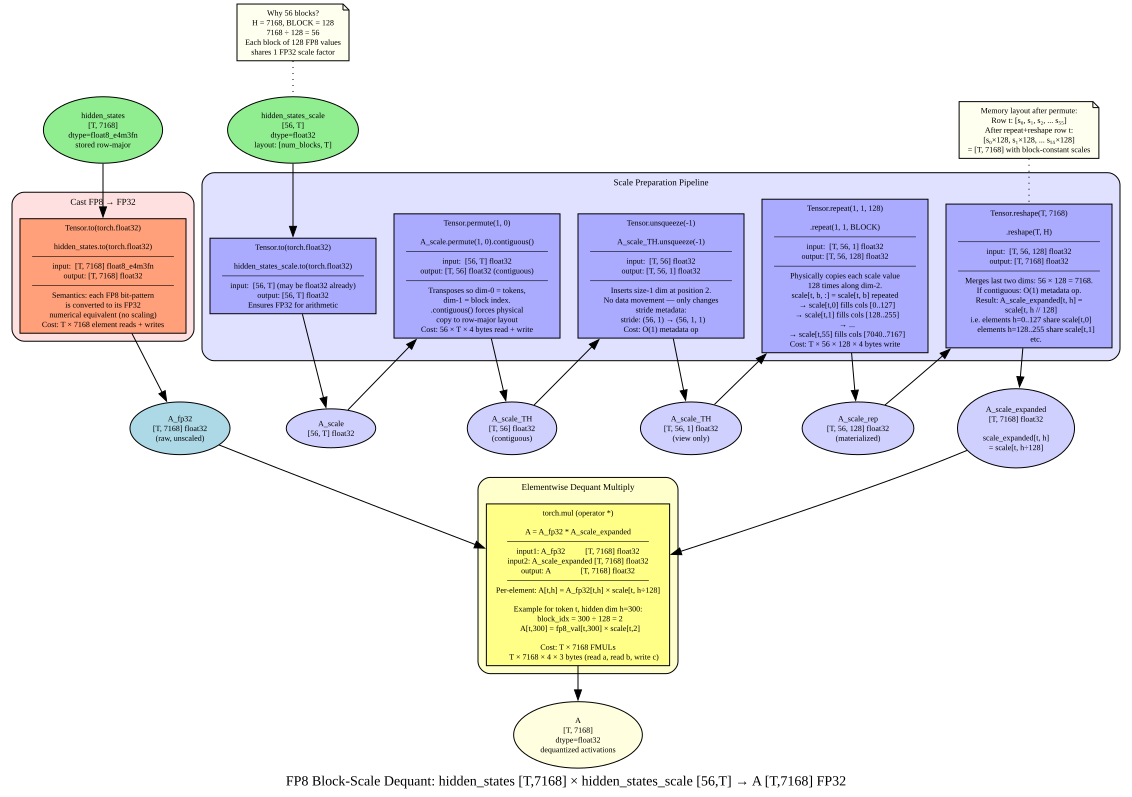

In [31]:
dq = graphviz.Digraph('Dequant_HiddenStates', format='svg')
dq.attr(rankdir='TB',
        label='FP8 Block-Scale Dequant: hidden_states [T,7168] × hidden_states_scale [56,T] → A [T,7168] FP32',
        fontsize='14', compound='true')
dq.attr('node', fontsize='8')
dq.attr('edge', fontsize='7')

# ── Inputs ──
dq.node('hs', 'hidden_states\n[T, 7168]\ndtype=float8_e4m3fn\nstored row-major', shape='ellipse', style='filled', fillcolor='lightgreen')
dq.node('hs_scale', 'hidden_states_scale\n[56, T]\ndtype=float32\nlayout: [num_blocks, T]', shape='ellipse', style='filled', fillcolor='lightgreen')

# ── Output ──
dq.node('A', 'A\n[T, 7168]\ndtype=float32\ndequantized activations', shape='ellipse', style='filled', fillcolor='lightyellow')

# ════════════════════════════════════════
# LEFT BRANCH: hidden_states → FP32
# ════════════════════════════════════════
with dq.subgraph(name='cluster_cast') as c:
    c.attr(label='Cast FP8 → FP32', style='rounded,filled', fillcolor='#FFE0E0', fontsize='9')

    c.node('cast_fp32', 'Tensor.to(torch.float32)\n\nhidden_states.to(torch.float32)\n'
           '─────────────────────────\n'
           'input:  [T, 7168] float8_e4m3fn\n'
           'output: [T, 7168] float32\n'
           '─────────────────────────\n'
           'Semantics: each FP8 bit-pattern\n'
           'is converted to its FP32\n'
           'numerical equivalent (no scaling)\n'
           'Cost: T × 7168 element reads + writes',
           shape='box', style='filled', fillcolor='lightsalmon')

dq.node('A_fp32', 'A_fp32\n[T, 7168] float32\n(raw, unscaled)',
        shape='ellipse', style='filled', fillcolor='lightblue')

dq.edge('hs', 'cast_fp32')
dq.edge('cast_fp32', 'A_fp32')

# ════════════════════════════════════════
# RIGHT BRANCH: scale → expanded [T, 7168]
# ════════════════════════════════════════
with dq.subgraph(name='cluster_scale_prep') as c:
    c.attr(label='Scale Preparation Pipeline', style='rounded,filled', fillcolor='#E0E0FF', fontsize='9')

    # Step 1: cast scale to FP32 (may already be FP32, but ref does .to(float32))
    c.node('cast_scale', 'Tensor.to(torch.float32)\n\nhidden_states_scale.to(torch.float32)\n'
           '─────────────────────────\n'
           'input:  [56, T] (may be float32 already)\n'
           'output: [56, T] float32\n'
           'Ensures FP32 for arithmetic',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 2: permute
    c.node('permute', 'Tensor.permute(1, 0)\n\nA_scale.permute(1, 0).contiguous()\n'
           '─────────────────────────\n'
           'input:  [56, T] float32\n'
           'output: [T, 56] float32 (contiguous)\n'
           '─────────────────────────\n'
           'Transposes so dim-0 = tokens,\n'
           'dim-1 = block index.\n'
           '.contiguous() forces physical\n'
           'copy to row-major layout\n'
           'Cost: 56 × T × 4 bytes read + write',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 3: unsqueeze
    c.node('unsqueeze', 'Tensor.unsqueeze(-1)\n\nA_scale_TH.unsqueeze(-1)\n'
           '─────────────────────────\n'
           'input:  [T, 56] float32\n'
           'output: [T, 56, 1] float32\n'
           '─────────────────────────\n'
           'Inserts size-1 dim at position 2.\n'
           'No data movement — only changes\n'
           'stride metadata:\n'
           '  stride: (56, 1) → (56, 1, 1)\n'
           'Cost: O(1) metadata op',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 4: repeat
    c.node('repeat', 'Tensor.repeat(1, 1, 128)\n\n.repeat(1, 1, BLOCK)\n'
           '─────────────────────────\n'
           'input:  [T, 56, 1] float32\n'
           'output: [T, 56, 128] float32\n'
           '─────────────────────────\n'
           'Physically copies each scale value\n'
           '128 times along dim-2.\n'
           'scale[t, b, :] = scale[t, b] repeated\n'
           '  → scale[t,0] fills cols [0..127]\n'
           '  → scale[t,1] fills cols [128..255]\n'
           '  → ...\n'
           '  → scale[t,55] fills cols [7040..7167]\n'
           'Cost: T × 56 × 128 × 4 bytes write',
           shape='box', style='filled', fillcolor='#AAAAFF')

    # Step 5: reshape
    c.node('reshape', 'Tensor.reshape(T, 7168)\n\n.reshape(T, H)\n'
           '─────────────────────────\n'
           'input:  [T, 56, 128] float32\n'
           'output: [T, 7168] float32\n'
           '─────────────────────────\n'
           'Merges last two dims: 56 × 128 = 7168.\n'
           'If contiguous: O(1) metadata op.\n'
           'Result: A_scale_expanded[t, h] =\n'
           '  scale[t, h // 128]\n'
           '  i.e. elements h=0..127 share scale[t,0]\n'
           '       elements h=128..255 share scale[t,1]\n'
           '       etc.',
           shape='box', style='filled', fillcolor='#AAAAFF')

# Scale intermediates
dq.node('s_fp32', 'A_scale\n[56, T] float32', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_TH', 'A_scale_TH\n[T, 56] float32\n(contiguous)', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_uns', 'A_scale_TH\n[T, 56, 1] float32\n(view only)', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_rep', 'A_scale_rep\n[T, 56, 128] float32\n(materialized)', shape='ellipse', style='filled', fillcolor='#D0D0FF')
dq.node('s_exp', 'A_scale_expanded\n[T, 7168] float32\n\nscale_expanded[t, h]\n= scale[t, h÷128]',
        shape='ellipse', style='filled', fillcolor='#D0D0FF')

# Scale edges
dq.edge('hs_scale', 'cast_scale')
dq.edge('cast_scale', 's_fp32')
dq.edge('s_fp32', 'permute')
dq.edge('permute', 's_TH')
dq.edge('s_TH', 'unsqueeze')
dq.edge('unsqueeze', 's_uns')
dq.edge('s_uns', 'repeat')
dq.edge('repeat', 's_rep')
dq.edge('s_rep', 'reshape')
dq.edge('reshape', 's_exp')

# ════════════════════════════════════════
# FINAL: Elementwise Multiply
# ════════════════════════════════════════
with dq.subgraph(name='cluster_mul') as c:
    c.attr(label='Elementwise Dequant Multiply', style='rounded,filled', fillcolor='#FFFFCC', fontsize='9')

    c.node('mul', 'torch.mul (operator *)\n\nA = A_fp32 * A_scale_expanded\n'
           '─────────────────────────\n'
           'input1: A_fp32          [T, 7168] float32\n'
           'input2: A_scale_expanded [T, 7168] float32\n'
           'output: A               [T, 7168] float32\n'
           '─────────────────────────\n'
           'Per-element: A[t,h] = A_fp32[t,h] × scale[t, h÷128]\n'
           '\n'
           'Example for token t, hidden dim h=300:\n'
           '  block_idx = 300 ÷ 128 = 2\n'
           '  A[t,300] = fp8_val[t,300] × scale[t,2]\n'
           '\n'
           'Cost: T × 7168 FMULs\n'
           '      T × 7168 × 4 × 3 bytes (read a, read b, write c)',
           shape='box', style='filled', fillcolor='#FFFF88')

dq.edge('A_fp32', 'mul')
dq.edge('s_exp', 'mul')
dq.edge('mul', 'A')

# ════════════════════════════════════════
# Annotations
# ════════════════════════════════════════
dq.node('note1',
        'Why 56 blocks?\n'
        'H = 7168, BLOCK = 128\n'
        '7168 ÷ 128 = 56\n'
        'Each block of 128 FP8 values\n'
        'shares 1 FP32 scale factor',
        shape='note', style='filled', fillcolor='#FFFFF0', fontsize='8')

dq.node('note2',
        'Memory layout after permute:\n'
        'Row t: [s₀, s₁, s₂, ... s₅₅]\n'
        'After repeat+reshape row t:\n'
        '[s₀×128, s₁×128, ... s₅₅×128]\n'
        '= [T, 7168] with block-constant scales',
        shape='note', style='filled', fillcolor='#FFFFF0', fontsize='8')

dq.edge('note1', 'hs_scale', style='dotted', arrowhead='none')
dq.edge('note2', 'reshape', style='dotted', arrowhead='none')

display(dq)

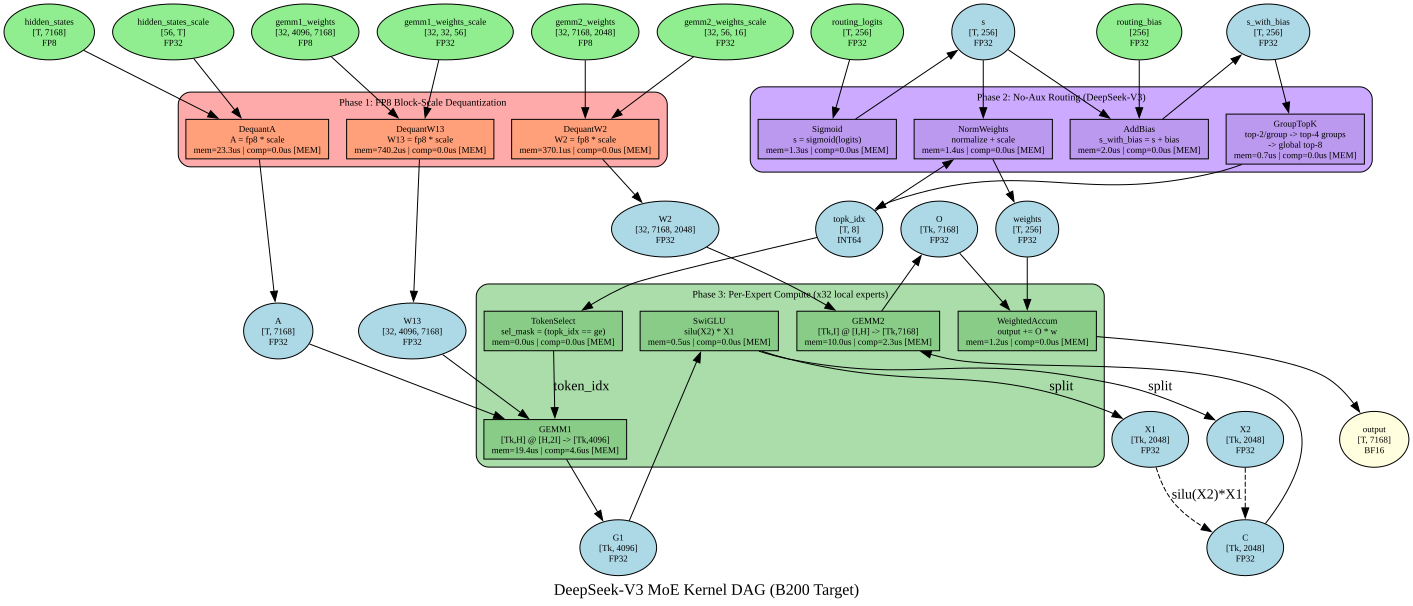

In [32]:
import json, os, math

# ── Load measured B200 hardware parameters ──
for _p in ["hw_cost_primitives.json", "deepdive/hw_cost_primitives.json"]:
    if os.path.exists(_p):
        with open(_p) as _f:
            _hw = json.load(_f)
        break

hbm_bw_bps = _hw["data_movement"]["hbm_copy"]["measurements"][-1]["bandwidth_GBps"] * 1e9  # bytes/s
bf16_fps   = _hw["compute"]["bf16_gemm"]["peak_tflops"] * 1e12   # flops/s (TF32 ~ BF16)
fp8_fps    = _hw["compute"]["fp8_gemm"]["peak_tflops"] * 1e12

E_G = E_global
Tk  = T * TOP_K // E_G  # avg tokens per expert

def _cost_str(read_bytes, write_bytes, flops=0, dtype='bf16'):
    """Return 'mem=X us | comp=Y us [BOUND]' string."""
    mem_us  = (read_bytes + write_bytes) / (hbm_bw_bps / 1e6)
    peak    = fp8_fps if dtype == 'fp8' else bf16_fps
    comp_us = flops / (peak / 1e6) if flops > 0 else 0
    bound   = 'MEM' if mem_us >= comp_us else 'COMPUTE'
    return f"mem={mem_us:.1f}us | comp={comp_us:.1f}us [{bound}]"

# Pre-compute cost strings for each op
c_dqA   = _cost_str(T*H*1 + 56*T*4,    T*H*4,                dtype='fp8')
c_dqW13 = _cost_str(E_local*2*I*H*1 + E_local*32*56*4, E_local*2*I*H*4, dtype='fp8')
c_dqW2  = _cost_str(E_local*H*I*1 + E_local*56*16*4,   E_local*H*I*4,   dtype='fp8')
c_sig   = _cost_str(T*E_G*4,       T*E_G*4,   flops=T*E_G*5)
c_abias = _cost_str(T*E_G*4*2,     T*E_G*4,   flops=T*E_G)
c_gtk   = _cost_str(T*E_G*4,       T*8*8,     flops=T*E_G*10)
c_nw    = _cost_str(T*E_G*4 + T*8*8, T*E_G*4, flops=T*E_G*3)
c_ts    = _cost_str(T*8*8,         T*4,       flops=T*8)
c_g1    = _cost_str(Tk*H*4 + 2*I*H*4, Tk*2*I*4, flops=2*Tk*H*2*I)
c_swg   = _cost_str(Tk*2*I*4,     Tk*I*4,    flops=Tk*I*5)
c_g2    = _cost_str(Tk*I*4 + H*I*4,   Tk*H*4, flops=2*Tk*I*H)
c_wa    = _cost_str(Tk*H*4 + Tk*4,    Tk*H*4, flops=Tk*H*2)

dot = graphviz.Digraph('MoE_Kernel_DAG', format='svg')
dot.attr(rankdir='TB', label='DeepSeek-V3 MoE Kernel DAG (B200 Target)', fontsize='16', compound='true')
dot.attr('node', fontsize='9')

# === Input Tensors (green) ===
inputs = {
    'routing_logits':      '[T, 256]\nFP32',
    'routing_bias':        '[256]\nFP32',
    'hidden_states':       '[T, 7168]\nFP8',
    'hidden_states_scale': '[56, T]\nFP32',
    'gemm1_weights':       '[32, 4096, 7168]\nFP8',
    'gemm1_weights_scale': '[32, 32, 56]\nFP32',
    'gemm2_weights':       '[32, 7168, 2048]\nFP8',
    'gemm2_weights_scale': '[32, 56, 16]\nFP32',
}
for name, shape in inputs.items():
    dot.node(name, f'{name}\n{shape}', shape='ellipse', style='filled', fillcolor='lightgreen')

# === Output Tensor (yellow) ===
dot.node('output', 'output\n[T, 7168]\nBF16', shape='ellipse', style='filled', fillcolor='lightyellow')

# === Intermediate Tensors (blue) ===
intermediates = {
    'A':          '[T, 7168]\nFP32',
    'W13':        '[32, 4096, 7168]\nFP32',
    'W2':         '[32, 7168, 2048]\nFP32',
    's':          '[T, 256]\nFP32',
    's_with_bias':'[T, 256]\nFP32',
    'topk_idx':   '[T, 8]\nINT64',
    'weights':    '[T, 256]\nFP32',
    'G1':         '[Tk, 4096]\nFP32',
    'X1':         '[Tk, 2048]\nFP32',
    'X2':         '[Tk, 2048]\nFP32',
    'C':          '[Tk, 2048]\nFP32',
    'O':          '[Tk, 7168]\nFP32',
}
for name, shape in intermediates.items():
    dot.node(name, f'{name}\n{shape}', shape='ellipse', style='filled', fillcolor='lightblue')

# === Phase 1: FP8 Dequantization (salmon) ===
with dot.subgraph(name='cluster_dequant') as c:
    c.attr(label='Phase 1: FP8 Block-Scale Dequantization', style='rounded,filled',
           fillcolor='#FFAAAA', fontsize='10')
    c.node('DequantA',   'DequantA\nA = fp8 * scale\n' + c_dqA,   shape='box', style='filled', fillcolor='lightsalmon')
    c.node('DequantW13', 'DequantW13\nW13 = fp8 * scale\n' + c_dqW13, shape='box', style='filled', fillcolor='lightsalmon')
    c.node('DequantW2',  'DequantW2\nW2 = fp8 * scale\n' + c_dqW2,  shape='box', style='filled', fillcolor='lightsalmon')

# Dequant edges
dot.edge('hidden_states', 'DequantA')
dot.edge('hidden_states_scale', 'DequantA')
dot.edge('DequantA', 'A')

dot.edge('gemm1_weights', 'DequantW13')
dot.edge('gemm1_weights_scale', 'DequantW13')
dot.edge('DequantW13', 'W13')

dot.edge('gemm2_weights', 'DequantW2')
dot.edge('gemm2_weights_scale', 'DequantW2')
dot.edge('DequantW2', 'W2')

# === Phase 2: Routing (light purple) ===
with dot.subgraph(name='cluster_routing') as c:
    c.attr(label='Phase 2: No-Aux Routing (DeepSeek-V3)', style='rounded,filled',
           fillcolor='#CCAAFF', fontsize='10')
    c.node('Sigmoid',     'Sigmoid\ns = sigmoid(logits)\n' + c_sig,     shape='box', style='filled', fillcolor='#BB99EE')
    c.node('AddBias',     'AddBias\ns_with_bias = s + bias\n' + c_abias, shape='box', style='filled', fillcolor='#BB99EE')
    c.node('GroupTopK',   'GroupTopK\ntop-2/group -> top-4 groups\n-> global top-8\n' + c_gtk, shape='box', style='filled', fillcolor='#BB99EE')
    c.node('NormWeights', 'NormWeights\nnormalize + scale\n' + c_nw,     shape='box', style='filled', fillcolor='#BB99EE')

dot.edge('routing_logits', 'Sigmoid')
dot.edge('Sigmoid', 's')
dot.edge('s', 'AddBias')
dot.edge('routing_bias', 'AddBias')
dot.edge('AddBias', 's_with_bias')
dot.edge('s_with_bias', 'GroupTopK')
dot.edge('GroupTopK', 'topk_idx')
dot.edge('s', 'NormWeights')
dot.edge('topk_idx', 'NormWeights')
dot.edge('NormWeights', 'weights')

# === Phase 3: Expert Compute (green-ish) ===
with dot.subgraph(name='cluster_expert') as c:
    c.attr(label='Phase 3: Per-Expert Compute (x32 local experts)', style='rounded,filled',
           fillcolor='#AADDAA', fontsize='10')
    c.node('TokenSelect',  'TokenSelect\nsel_mask = (topk_idx == ge)\n' + c_ts,  shape='box', style='filled', fillcolor='#88CC88')
    c.node('GEMM1',        'GEMM1\n[Tk,H] @ [H,2I] -> [Tk,4096]\n' + c_g1,     shape='box', style='filled', fillcolor='#88CC88')
    c.node('SwiGLU',       'SwiGLU\nsilu(X2) * X1\n' + c_swg,                    shape='box', style='filled', fillcolor='#88CC88')
    c.node('GEMM2',        'GEMM2\n[Tk,I] @ [I,H] -> [Tk,7168]\n' + c_g2,      shape='box', style='filled', fillcolor='#88CC88')
    c.node('WeightedAccum','WeightedAccum\noutput += O * w\n' + c_wa,             shape='box', style='filled', fillcolor='#88CC88')

# Expert compute edges
dot.edge('topk_idx', 'TokenSelect')
dot.edge('TokenSelect', 'GEMM1', label='token_idx')
dot.edge('A', 'GEMM1')
dot.edge('W13', 'GEMM1')
dot.edge('GEMM1', 'G1')
dot.edge('G1', 'SwiGLU')
dot.edge('SwiGLU', 'X1', label='split')
dot.edge('SwiGLU', 'X2', label='split')
dot.edge('X1', 'C', label='silu(X2)*X1', style='dashed')
dot.edge('X2', 'C', style='dashed')
dot.edge('C', 'GEMM2')
dot.edge('W2', 'GEMM2')
dot.edge('GEMM2', 'O')
dot.edge('O', 'WeightedAccum')
dot.edge('weights', 'WeightedAccum')
dot.edge('WeightedAccum', 'output')

display(dot)

---
## Dependency-Based DAG

Same operations as above, but grouped by **data dependency chains** instead of phases.

**4 independent chains** (can execute in parallel) converge at 3 synchronization points:

| Chain | Color | Path | Needed at |
|-------|-------|------|-----------|
| A — Hidden States | Salmon | `hidden_states` + scale → DequantA → **A** | GEMM1 |
| B — GEMM1 Weights | Blue | `gemm1_weights` + scale → DequantW13 → **W13** | GEMM1 |
| C — GEMM2 Weights | Teal | `gemm2_weights` + scale → DequantW2 → **W2** | GEMM2 |
| D — Routing | Purple | `routing_logits` + bias → Sigmoid → … → **topk_idx**, **weights** | GEMM1, Accum |

Bold red convergence edges show where independent chains must synchronize.

---
## Placeholder Roofline Estimates (B200)

Rough arithmetic intensity and bottleneck analysis per operation.

In [33]:
import math

hbm_bw = B200['hbm_bandwidth_TB_s'] * 1e12  # bytes/s
fp8_flops = B200['fp8_tflops'] * 1e12
bf16_flops = B200['bf16_tflops'] * 1e12

# Arithmetic intensity crossover (flops/byte)
ai_crossover_fp8 = fp8_flops / hbm_bw
ai_crossover_bf16 = bf16_flops / hbm_bw

print(f"B200 Roofline Crossover Points (placeholder):")
print(f"  FP8:  {ai_crossover_fp8:.1f} flops/byte")
print(f"  BF16: {ai_crossover_bf16:.1f} flops/byte")
print()

# Per-operation estimates
Tk = T * TOP_K // E_global  # avg tokens per expert ~ T*8/256
print(f"Assuming T={T}, avg Tk per expert ~ {Tk}")
print()

ops_table = [
    ('DequantA',    'Pointwise', T * H * 2,          T * H * (1 + 4 + 4),     'FP8->FP32 elementwise mul'),
    ('DequantW13',  'Pointwise', E_local * 2*I * H * 2, E_local * 2*I * H * (1+4+4), 'FP8->FP32 elementwise mul'),
    ('DequantW2',   'Pointwise', E_local * H * I * 2,   E_local * H * I * (1+4+4),   'FP8->FP32 elementwise mul'),
    ('Routing',     'Mixed',     T * E_global * 20,   T * E_global * 4 * 3,    'sigmoid + group topk + normalize'),
    ('GEMM1 (all)', 'MatMul',    E_local * 2 * Tk * H * I * 2, E_local * (Tk*H + 2*I*H + Tk*2*I) * 4, 'per-expert [Tk,H]@[H,2I]'),
    ('SwiGLU',      'Pointwise', E_local * Tk * I * 5,  E_local * Tk * I * 4 * 3, 'silu + mul'),
    ('GEMM2 (all)', 'MatMul',    E_local * 2 * Tk * I * H, E_local * (Tk*I + H*I + Tk*H) * 4, 'per-expert [Tk,I]@[I,H]'),
    ('Accum',       'Pointwise', E_local * Tk * H * 2,  E_local * Tk * H * 4 * 2, 'weighted add'),
]

print(f'{"Op":<16} {"Type":<10} {"FLOPs":>14} {"Bytes":>14} {"AI (F/B)":>10} {"Bottleneck":<12} Notes')
print('-' * 100)
for name, typ, flops, bytes_, notes in ops_table:
    ai = flops / max(bytes_, 1)
    crossover = ai_crossover_fp8 if 'FP8' in notes else ai_crossover_bf16
    bottleneck = 'Compute' if ai > crossover else 'Memory'
    print(f'{name:<16} {typ:<10} {flops:>14,} {bytes_:>14,} {ai:>10.1f} {bottleneck:<12} {notes}')

B200 Roofline Crossover Points (placeholder):
  FP8:  562.5 flops/byte
  BF16: 281.2 flops/byte

Assuming T=4096, avg Tk per expert ~ 128

Op               Type                FLOPs          Bytes   AI (F/B) Bottleneck   Notes
----------------------------------------------------------------------------------------------------
DequantA         Pointwise      58,720,256    264,241,152        0.2 Memory       FP8->FP32 elementwise mul
DequantW13       Pointwise   1,879,048,192  8,455,716,864        0.2 Memory       FP8->FP32 elementwise mul
DequantW2        Pointwise     939,524,096  4,227,858,432        0.2 Memory       FP8->FP32 elementwise mul
Routing          Mixed          20,971,520     12,582,912        1.7 Memory       sigmoid + group topk + normalize
GEMM1 (all)      MatMul     240,518,168,576  3,942,645,760       61.0 Memory       per-expert [Tk,H]@[H,2I]
SwiGLU           Pointwise      41,943,040    100,663,296        0.4 Memory       silu + mul
GEMM2 (all)      MatMul     120,

---
## Memory Footprint Summary

In [34]:
mem = {
    'routing_logits':      (T * E_global * 4,       'FP32'),
    'routing_bias':        (E_global * 4,            'FP32'),
    'hidden_states':       (T * H * 1,               'FP8'),
    'hidden_states_scale': (56 * T * 4,              'FP32'),
    'gemm1_weights':       (E_local * 2*I * H * 1,   'FP8'),
    'gemm1_weights_scale': (E_local * 32 * 56 * 4,   'FP32'),
    'gemm2_weights':       (E_local * H * I * 1,     'FP8'),
    'gemm2_weights_scale': (E_local * 56 * 16 * 4,   'FP32'),
    'A (dequant)':         (T * H * 4,               'FP32'),
    'W13 (dequant)':       (E_local * 2*I * H * 4,   'FP32'),
    'W2 (dequant)':        (E_local * H * I * 4,     'FP32'),
    'output':              (T * H * 2,               'BF16'),
}

total = 0
print(f'{"Tensor":<25} {"Size (MB)":>12} {"Dtype":<6}')
print('-' * 45)
for name, (size_bytes, dtype) in mem.items():
    mb = size_bytes / (1024**2)
    total += size_bytes
    print(f'{name:<25} {mb:>12.2f} {dtype:<6}')
print('-' * 45)
print(f'{"TOTAL":<25} {total/(1024**2):>12.2f} MB')
print(f'{"":<25} {total/(1024**3):>12.2f} GB')

Tensor                       Size (MB) Dtype 
---------------------------------------------
routing_logits                    4.00 FP32  
routing_bias                      0.00 FP32  
hidden_states                    28.00 FP8   
hidden_states_scale               0.88 FP32  
gemm1_weights                   896.00 FP8   
gemm1_weights_scale               0.22 FP32  
gemm2_weights                   448.00 FP8   
gemm2_weights_scale               0.11 FP32  
A (dequant)                     112.00 FP32  
W13 (dequant)                  3584.00 FP32  
W2 (dequant)                   1792.00 FP32  
output                           56.00 BF16  
---------------------------------------------
TOTAL                          6921.20 MB
                                  6.76 GB


---
## Critical Path DAG (Simplified)

Shows the dataflow critical path: Dequant -> Routing + Expert Compute -> Output

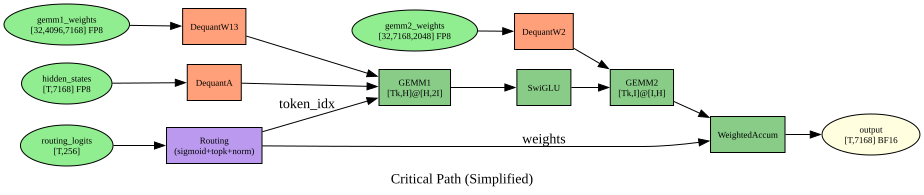

In [35]:
cp = graphviz.Digraph('CriticalPath', format='svg')
cp.attr(rankdir='LR', label='Critical Path (Simplified)', fontsize='14')
cp.attr('node', fontsize='9')

# Simplified nodes
cp.node('hs', 'hidden_states\n[T,7168] FP8', shape='ellipse', style='filled', fillcolor='lightgreen')
cp.node('w13', 'gemm1_weights\n[32,4096,7168] FP8', shape='ellipse', style='filled', fillcolor='lightgreen')
cp.node('w2', 'gemm2_weights\n[32,7168,2048] FP8', shape='ellipse', style='filled', fillcolor='lightgreen')
cp.node('rl', 'routing_logits\n[T,256]', shape='ellipse', style='filled', fillcolor='lightgreen')

cp.node('dqA', 'DequantA', shape='box', style='filled', fillcolor='lightsalmon')
cp.node('dqW13', 'DequantW13', shape='box', style='filled', fillcolor='lightsalmon')
cp.node('dqW2', 'DequantW2', shape='box', style='filled', fillcolor='lightsalmon')
cp.node('route', 'Routing\n(sigmoid+topk+norm)', shape='box', style='filled', fillcolor='#BB99EE')
cp.node('gemm1', 'GEMM1\n[Tk,H]@[H,2I]', shape='box', style='filled', fillcolor='#88CC88')
cp.node('swiglu', 'SwiGLU', shape='box', style='filled', fillcolor='#88CC88')
cp.node('gemm2', 'GEMM2\n[Tk,I]@[I,H]', shape='box', style='filled', fillcolor='#88CC88')
cp.node('accum', 'WeightedAccum', shape='box', style='filled', fillcolor='#88CC88')
cp.node('out', 'output\n[T,7168] BF16', shape='ellipse', style='filled', fillcolor='lightyellow')

cp.edge('hs', 'dqA')
cp.edge('w13', 'dqW13')
cp.edge('w2', 'dqW2')
cp.edge('rl', 'route')
cp.edge('dqA', 'gemm1')
cp.edge('dqW13', 'gemm1')
cp.edge('route', 'gemm1', label='token_idx')
cp.edge('gemm1', 'swiglu')
cp.edge('swiglu', 'gemm2')
cp.edge('dqW2', 'gemm2')
cp.edge('gemm2', 'accum')
cp.edge('route', 'accum', label='weights')
cp.edge('accum', 'out')

display(cp)

---
## Dependency-Based DAG

Same operations as above, but grouped by **data dependency chains** instead of phases.

**4 independent chains** (can execute in parallel) converge at 3 synchronization points:

| Chain | Color | Path | Needed at |
|-------|-------|------|-----------|
| A — Hidden States | Salmon | `hidden_states` + scale → DequantA → **A** | GEMM1 |
| B — GEMM1 Weights | Blue | `gemm1_weights` + scale → DequantW13 → **W13** | GEMM1 |
| C — GEMM2 Weights | Teal | `gemm2_weights` + scale → DequantW2 → **W2** | GEMM2 |
| D — Routing | Purple | `routing_logits` + bias → Sigmoid → … → **topk_idx**, **weights** | GEMM1, Accum |

Bold red convergence edges show where independent chains must synchronize.

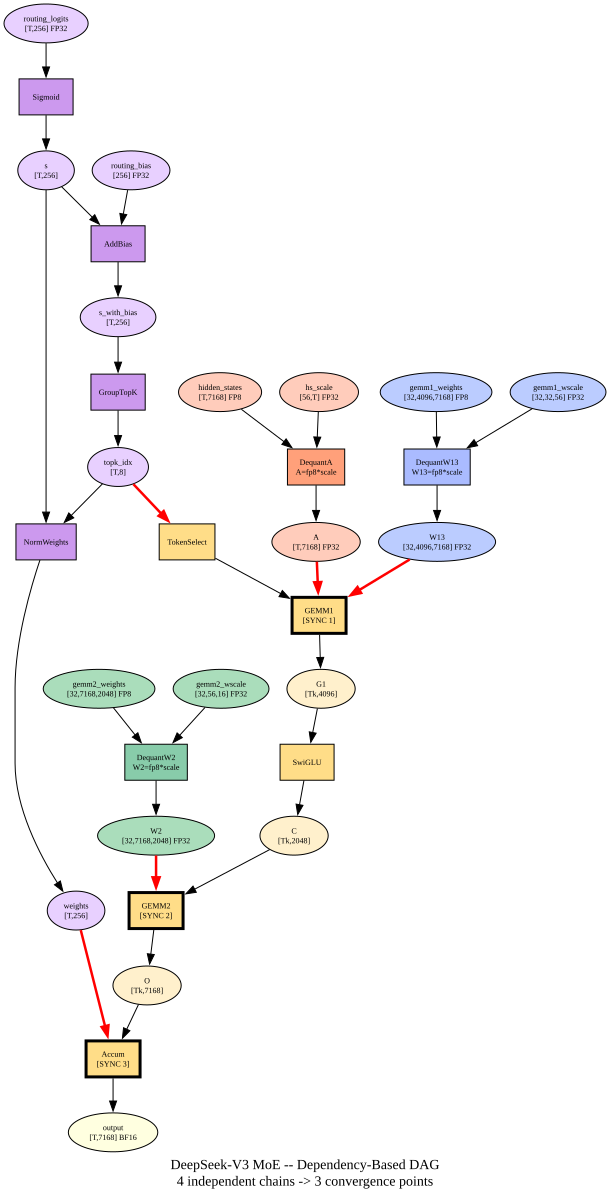

In [36]:
# Dependency-Based DAG — no clusters (avoids Windows graphviz crash)
# Chains distinguished by node color only

dep = graphviz.Digraph('DepDAG', format='svg')
dep.attr(rankdir='TB',
         label='DeepSeek-V3 MoE -- Dependency-Based DAG\n'
               '4 independent chains -> 3 convergence points',
         fontsize='14')
dep.attr('node', fontsize='8', style='filled')
dep.attr('edge', fontsize='7')

# ── Chain A: Hidden States Dequant (salmon tones) ──
dep.node('hs',   'hidden_states\n[T,7168] FP8',     shape='ellipse', fillcolor='#FFCCBB')
dep.node('hs_s', 'hs_scale\n[56,T] FP32',           shape='ellipse', fillcolor='#FFCCBB')
dep.node('DqA',  'DequantA\nA=fp8*scale',            shape='box',     fillcolor='lightsalmon')
dep.node('A',    'A\n[T,7168] FP32',                 shape='ellipse', fillcolor='#FFCCBB')
dep.edge('hs', 'DqA')
dep.edge('hs_s', 'DqA')
dep.edge('DqA', 'A')

# ── Chain B: GEMM1 Weights Dequant (blue tones) ──
dep.node('w13',   'gemm1_weights\n[32,4096,7168] FP8',  shape='ellipse', fillcolor='#BBCCFF')
dep.node('w13_s', 'gemm1_wscale\n[32,32,56] FP32',      shape='ellipse', fillcolor='#BBCCFF')
dep.node('DqW13', 'DequantW13\nW13=fp8*scale',           shape='box',     fillcolor='#AABBFF')
dep.node('W13',   'W13\n[32,4096,7168] FP32',            shape='ellipse', fillcolor='#BBCCFF')
dep.edge('w13', 'DqW13')
dep.edge('w13_s', 'DqW13')
dep.edge('DqW13', 'W13')

# ── Chain C: GEMM2 Weights Dequant (teal tones) ──
dep.node('w2',   'gemm2_weights\n[32,7168,2048] FP8',   shape='ellipse', fillcolor='#AADDBB')
dep.node('w2_s', 'gemm2_wscale\n[32,56,16] FP32',       shape='ellipse', fillcolor='#AADDBB')
dep.node('DqW2', 'DequantW2\nW2=fp8*scale',              shape='box',     fillcolor='#88CCAA')
dep.node('W2',   'W2\n[32,7168,2048] FP32',              shape='ellipse', fillcolor='#AADDBB')
dep.edge('w2', 'DqW2')
dep.edge('w2_s', 'DqW2')
dep.edge('DqW2', 'W2')

# ── Chain D: Routing (purple tones) ──
dep.node('rl',   'routing_logits\n[T,256] FP32', shape='ellipse', fillcolor='#E8D0FF')
dep.node('rb',   'routing_bias\n[256] FP32',     shape='ellipse', fillcolor='#E8D0FF')
dep.node('Sig',  'Sigmoid',                       shape='box',     fillcolor='#CC99EE')
dep.node('s',    's\n[T,256]',                     shape='ellipse', fillcolor='#E8D0FF')
dep.node('AB',   'AddBias',                        shape='box',     fillcolor='#CC99EE')
dep.node('swb',  's_with_bias\n[T,256]',           shape='ellipse', fillcolor='#E8D0FF')
dep.node('GTK',  'GroupTopK',                       shape='box',     fillcolor='#CC99EE')
dep.node('tidx', 'topk_idx\n[T,8]',               shape='ellipse', fillcolor='#E8D0FF')
dep.node('NW',   'NormWeights',                     shape='box',     fillcolor='#CC99EE')
dep.node('wts',  'weights\n[T,256]',               shape='ellipse', fillcolor='#E8D0FF')
dep.edge('rl', 'Sig')
dep.edge('Sig', 's')
dep.edge('s', 'AB')
dep.edge('rb', 'AB')
dep.edge('AB', 'swb')
dep.edge('swb', 'GTK')
dep.edge('GTK', 'tidx')
dep.edge('s', 'NW')
dep.edge('tidx', 'NW')
dep.edge('NW', 'wts')

# ── Convergence zone (yellow/gray tones) ──
dep.node('TS',  'TokenSelect',  shape='box', fillcolor='#FFDD88')
dep.node('GM1', 'GEMM1\n[SYNC 1]', shape='box', fillcolor='#FFDD88', penwidth='3')
dep.node('G1',  'G1\n[Tk,4096]',   shape='ellipse', fillcolor='#FFF0CC')
dep.node('SWG', 'SwiGLU',          shape='box', fillcolor='#FFDD88')
dep.node('C',   'C\n[Tk,2048]',    shape='ellipse', fillcolor='#FFF0CC')
dep.node('GM2', 'GEMM2\n[SYNC 2]', shape='box', fillcolor='#FFDD88', penwidth='3')
dep.node('O',   'O\n[Tk,7168]',    shape='ellipse', fillcolor='#FFF0CC')
dep.node('WA',  'Accum\n[SYNC 3]', shape='box', fillcolor='#FFDD88', penwidth='3')
dep.node('out', 'output\n[T,7168] BF16', shape='ellipse', fillcolor='lightyellow')

# ── Cross-chain convergence edges (bold red) ──
rs = {'color': 'red', 'penwidth': '2.5'}
dep.edge('tidx', 'TS',  **rs)
dep.edge('A',    'GM1', **rs)
dep.edge('W13',  'GM1', **rs)
dep.edge('W2',   'GM2', **rs)
dep.edge('wts',  'WA',  **rs)

# ── Sequential edges in convergence zone (black) ──
dep.edge('TS', 'GM1')
dep.edge('GM1', 'G1')
dep.edge('G1', 'SWG')
dep.edge('SWG', 'C')
dep.edge('C', 'GM2')
dep.edge('GM2', 'O')
dep.edge('O', 'WA')
dep.edge('WA', 'out')

display(dep)

---
## Per-Op Cost Model (kernel_ref.py on B200)

Uses **measured** B200 hardware primitives from `hw_cost_primitives.json` to predict
the latency of each op in `kernel_ref.py`.

**Key modeling rules:**
- Each PyTorch eager op = 1 CUDA kernel launch
- `kernel_cost = max(launch_overhead, mem_time, compute_time)`
- `kernel_ref.py` is fully sequential — total = sum of all kernel costs
- FP32 matmul uses TF32 tensor cores (PyTorch default on Blackwell)
- All intermediates materialize to HBM (no fusion)

In [37]:
import json, os

# ── Load measured B200 hardware parameters ──
for p in ["hw_cost_primitives.json", "deepdive/hw_cost_primitives.json"]:
    if os.path.exists(p):
        with open(p) as f:
            hw = json.load(f)
        break

HBM_BW   = hw["data_movement"]["hbm_copy"]["measurements"][-1]["bandwidth_GBps"]  # ~6394 GB/s
LAUNCH    = hw["kernel_launch_overhead"]["estimated_overhead_us"]                   # ~12.6 us
TF32_PEAK = hw["compute"]["bf16_gemm"]["peak_tflops"]  # TF32 ≈ BF16 on B200 (~1674 TFLOPS)
BW        = HBM_BW * 1e3  # bytes/us

# ── Dimensions (T=4096) ──
T = 4096; H = 7168; I = 2048; E = 32; BLK = 128; TOP_K = 8; E_G = 256
Tk = T * TOP_K // E_G  # 128 avg tokens per expert

print(f"B200 Measured:  HBM BW = {HBM_BW:.0f} GB/s  |  Launch = {LAUNCH:.1f} us  |  TF32 = {TF32_PEAK:.0f} TFLOPS")
print(f"Dimensions:     T={T}  H={H}  I={I}  E_local={E}  Tk={Tk}")
print()

def kcost(read_bytes, write_bytes, flops=0):
    """Cost of one CUDA kernel. Returns (mem_us, comp_us, total_us)."""
    mem = (read_bytes + write_bytes) / BW
    comp = flops / (TF32_PEAK * 1e6) if flops > 0 else 0
    total = max(LAUNCH, mem, comp)
    return mem, comp, total

# ═══════════════════════════════════════════════════════════════════
# Per-op cost breakdown — each entry: (op_name, n_kernels,
#   mem_us, comp_us, total_us, read_MB, write_MB)
# Matches kernel_ref.py execution order exactly.
# ═══════════════════════════════════════════════════════════════════

results = []

# ── DequantA: hidden_states.to(fp32) * scale_expanded ──
# 4 kernels: cast, permute+contiguous, repeat, multiply
dqa_costs = [
    kcost(T*H*1,     T*H*4),       # cast FP8->FP32
    kcost(56*T*4,    56*T*4),       # permute+contiguous
    kcost(56*T*4,    T*H*4),        # repeat(1,1,128)
    kcost(2*T*H*4,   T*H*4),        # A = fp32 * scale
]
dqa_mem  = sum(c[0] for c in dqa_costs)
dqa_comp = sum(c[1] for c in dqa_costs)
dqa_tot  = sum(c[2] for c in dqa_costs)
dqa_rd = (T*H*1 + 56*T*4 + 56*T*4 + 2*T*H*4) / 1e6
dqa_wr = (T*H*4 + 56*T*4 + T*H*4 + T*H*4) / 1e6
results.append(("DequantA", 4, dqa_mem, dqa_comp, dqa_tot, dqa_rd, dqa_wr))

# ── DequantW13: gemm1_weights.to(fp32) * scale_expanded ──
# 4 kernels: cast, repeat_interleave(dim=1), repeat_interleave(dim=2), multiply
dqw13_costs = [
    kcost(E*2*I*H*1,      E*2*I*H*4),       # cast FP8->FP32
    kcost(E*32*56*4,       E*2*I*56*4),       # repeat_interleave dim=1
    kcost(E*2*I*56*4,      E*2*I*H*4),        # repeat_interleave dim=2
    kcost(2*E*2*I*H*4,     E*2*I*H*4),        # W13 = fp32 * scale
]
dqw13_mem  = sum(c[0] for c in dqw13_costs)
dqw13_comp = sum(c[1] for c in dqw13_costs)
dqw13_tot  = sum(c[2] for c in dqw13_costs)
dqw13_rd = (E*2*I*H*1 + E*32*56*4 + E*2*I*56*4 + 2*E*2*I*H*4) / 1e6
dqw13_wr = (E*2*I*H*4 + E*2*I*56*4 + E*2*I*H*4 + E*2*I*H*4) / 1e6
results.append(("DequantW13", 4, dqw13_mem, dqw13_comp, dqw13_tot, dqw13_rd, dqw13_wr))

# ── DequantW2: gemm2_weights.to(fp32) * scale_expanded ──
dqw2_costs = [
    kcost(E*H*I*1,         E*H*I*4),          # cast
    kcost(E*56*16*4,        E*H*16*4),          # repeat_interleave dim=1
    kcost(E*H*16*4,         E*H*I*4),           # repeat_interleave dim=2
    kcost(2*E*H*I*4,        E*H*I*4),           # W2 = fp32 * scale
]
dqw2_mem  = sum(c[0] for c in dqw2_costs)
dqw2_comp = sum(c[1] for c in dqw2_costs)
dqw2_tot  = sum(c[2] for c in dqw2_costs)
dqw2_rd = (E*H*I*1 + E*56*16*4 + E*H*16*4 + 2*E*H*I*4) / 1e6
dqw2_wr = (E*H*I*4 + E*H*16*4 + E*H*I*4 + E*H*I*4) / 1e6
results.append(("DequantW2", 4, dqw2_mem, dqw2_comp, dqw2_tot, dqw2_rd, dqw2_wr))

# ── Routing: sigmoid -> add_bias -> group_topk -> normalize ──
# ~17 separate eager kernels, all on small tensors
n_routing_kernels = 17
routing_mem  = n_routing_kernels * (T * E_G * 4 * 2) / BW
routing_comp = n_routing_kernels * (T * E_G * 5) / (TF32_PEAK * 1e6)
routing_us = n_routing_kernels * LAUNCH  # all launch-overhead dominated
routing_rd = T * E_G * 4 * 3 / 1e6
routing_wr = (T*TOP_K*8 + T*E_G*4) / 1e6
results.append(("Routing", n_routing_kernels, routing_mem, routing_comp, routing_us, routing_rd, routing_wr))

# ── Expert loop (x32 experts) ──

# TokenSelect: 3 tiny kernels
ts_mem_per  = 3 * (T * TOP_K * 8) / BW
ts_comp_per = 0.0
ts_per = 3 * LAUNCH

# GEMM1: index_select + matmul
g1_idx = kcost(Tk*H*4, 0)
g1_mm  = kcost(Tk*H*4 + 2*I*H*4, Tk*2*I*4, flops=2*Tk*H*2*I)
g1_mem_per  = g1_idx[0] + g1_mm[0]
g1_comp_per = g1_idx[1] + g1_mm[1]
g1_per = g1_idx[2] + g1_mm[2]

# SwiGLU: 5 elementwise kernels
sw_mem_per  = 5 * (Tk * I * 4 * 2) / BW
sw_comp_per = 5 * (Tk * I) / (TF32_PEAK * 1e6)
sw_per = 5 * LAUNCH

# GEMM2: matmul
g2 = kcost(Tk*I*4 + H*I*4, Tk*H*4, flops=2*Tk*I*H)
g2_mem_per  = g2[0]
g2_comp_per = g2[1]
g2_per = g2[2]

# WeightedAccum: 3 kernels
wa_mem_per  = 3 * (Tk * H * 4) / BW
wa_comp_per = 0.0
wa_per = 3 * LAUNCH

expert_ops = [
    ("TokenSelect", 3, ts_mem_per,  ts_comp_per, ts_per),
    ("GEMM1",       2, g1_mem_per,  g1_comp_per, g1_per),
    ("SwiGLU",      5, sw_mem_per,  sw_comp_per, sw_per),
    ("GEMM2",       1, g2_mem_per,  g2_comp_per, g2_per),
    ("Accum",       3, wa_mem_per,  wa_comp_per, wa_per),
]

for name, nk, mem_per, comp_per, tot_per in expert_ops:
    results.append((f"{name} (x{E})", nk * E, mem_per * E, comp_per * E, tot_per * E, 0, 0))

# ═══════════════════════════════════════════════════════════════════
# Summary Table — shows mem, compute, and total latency per op
# ═══════════════════════════════════════════════════════════════════
total_us = sum(r[4] for r in results)
total_kernels = sum(r[1] for r in results)

print(f"{'Op':<22} {'Kernels':>7} {'Mem(us)':>9} {'Comp(us)':>9} {'Total(us)':>10} {'Bound':<8} {'%':>5}")
print("=" * 75)
for name, nk, mem_us, comp_us, tot_us, rd, wr in results:
    if tot_us <= nk * LAUNCH * 1.01:
        bound = "launch"
    elif mem_us >= comp_us:
        bound = "mem"
    else:
        bound = "compute"
    pct = tot_us / total_us * 100
    print(f"{name:<22} {nk:>7} {mem_us:>9.1f} {comp_us:>9.1f} {tot_us:>10.1f} {bound:<8} {pct:>4.1f}%")
print("=" * 75)
total_mem  = sum(r[2] for r in results)
total_comp = sum(r[3] for r in results)
print(f"{'TOTAL':<22} {total_kernels:>7} {total_mem:>9.1f} {total_comp:>9.1f} {total_us:>10.1f}")
print()

# ── Breakdown by category ──
dequant_us = sum(r[4] for r in results if r[0].startswith("Dequant"))
routing_total = sum(r[4] for r in results if r[0] == "Routing")
expert_total  = sum(r[4] for r in results if "(x" in r[0])

launch_only_us = sum(
    r[1] * LAUNCH for r in results
    if r[4] <= r[1] * LAUNCH * 1.01
)
mem_only_us = total_us - launch_only_us

print(f"Phase breakdown:")
print(f"  Dequantization:  {dequant_us:>8.1f} us  ({dequant_us/total_us*100:4.1f}%)")
print(f"  Routing:         {routing_total:>8.1f} us  ({routing_total/total_us*100:4.1f}%)")
print(f"  Expert loop:     {expert_total:>8.1f} us  ({expert_total/total_us*100:4.1f}%)")
print()
print(f"Cost breakdown:")
print(f"  Launch overhead: {launch_only_us:>8.1f} us  ({launch_only_us/total_us*100:4.1f}%)  [{total_kernels} kernels x {LAUNCH:.1f} us]")
print(f"  HBM data movement: {mem_only_us:>8.1f} us  ({mem_only_us/total_us*100:4.1f}%)")
print()
print(f"Predicted kernel_ref.py latency (T={T}): {total_us/1000:.1f} ms")

B200 Measured:  HBM BW = 6347 GB/s  |  Launch = 12.3 us  |  TF32 = 1628 TFLOPS
Dimensions:     T=4096  H=7168  I=2048  E_local=32  Tk=128

Op                     Kernels   Mem(us)  Comp(us)  Total(us) Bound        %
DequantA                     4      97.6       0.0      109.6 mem       1.0%
DequantW13                   4    3117.9       0.0     3125.5 mem      29.1%
DequantW2                    4    1558.9       0.0     1568.9 mem      14.6%
Routing                     17      22.5       0.1      208.9 launch    1.9%
TokenSelect (x32)           96       4.0       0.0     1179.8 launch   11.0%
GEMM1 (x32)                 64     639.7     147.7     1014.5 mem       9.4%
SwiGLU (x32)               160      52.9       0.0     1966.4 launch   18.3%
GEMM2 (x32)                 32     319.8      73.9      393.3 launch    3.7%
Accum (x32)                 96      55.5       0.0     1179.8 launch   11.0%
TOTAL                      477    5868.8     221.6    10746.8

Phase breakdown:
  Dequantiz

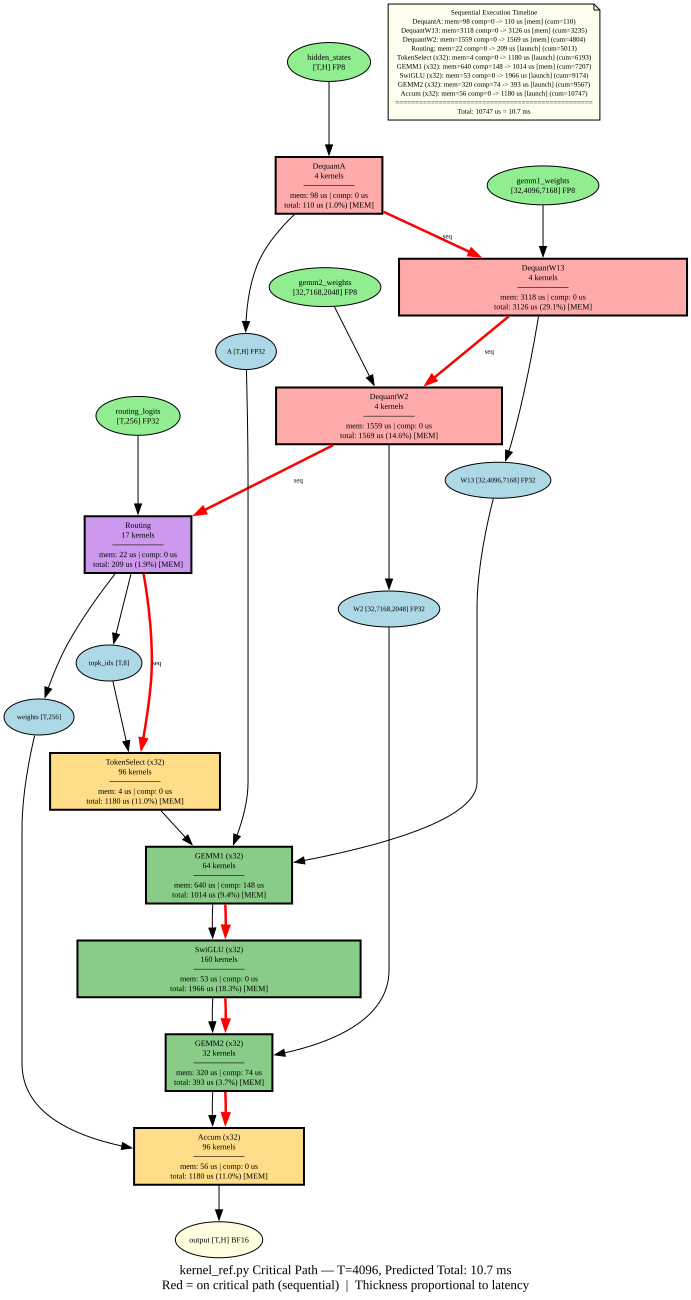

In [38]:
# ═══════════════════════════════════════════════════════════════════
# Critical Path DAG with Memory + Compute Latency Annotations
# ═══════════════════════════════════════════════════════════════════
# kernel_ref.py is fully sequential, so every op is on the critical path.
# Each node shows: mem latency | compute latency | total | bottleneck

import graphviz

g = graphviz.Digraph("CostDAG", format="svg")
g.attr(rankdir="TB",
       label=f"kernel_ref.py Critical Path — T={T}, Predicted Total: {total_us/1000:.1f} ms\n"
             f"Red = on critical path (sequential)  |  Thickness proportional to latency",
       fontsize="13", compound="true")
g.attr("node", fontsize="8", style="filled")
g.attr("edge", fontsize="7")

# ── Build op nodes with mem + compute latency labels ──
def op_node(g, nid, label, mem_us, comp_us, tot_us, color, shape="box"):
    width = max(0.8, min(4.0, tot_us / 500))
    pct = tot_us / total_us * 100
    if mem_us >= comp_us and tot_us > LAUNCH * 1.5:
        bound = "MEM"
    elif comp_us > mem_us:
        bound = "COMPUTE"
    else:
        bound = "LAUNCH"
    g.node(nid, f"{label}\n─────────\n"
                f"mem: {mem_us:.0f} us | comp: {comp_us:.0f} us\n"
                f"total: {tot_us:.0f} us ({pct:.1f}%) [{bound}]",
           shape=shape, fillcolor=color,
           width=str(width), penwidth="2")

# ── Inputs ──
for nid, lbl in [("hs", "hidden_states\n[T,H] FP8"),
                 ("w13_in", "gemm1_weights\n[32,4096,7168] FP8"),
                 ("w2_in", "gemm2_weights\n[32,7168,2048] FP8"),
                 ("rl", "routing_logits\n[T,256] FP32")]:
    g.node(nid, lbl, shape="ellipse", fillcolor="lightgreen")

# ── Phase 1: Dequantization ──
op_node(g, "DqA",   "DequantA\n4 kernels",   dqa_mem, dqa_comp, dqa_tot, "#FFAAAA")
op_node(g, "DqW13", "DequantW13\n4 kernels",  dqw13_mem, dqw13_comp, dqw13_tot, "#FFAAAA")
op_node(g, "DqW2",  "DequantW2\n4 kernels",   dqw2_mem, dqw2_comp, dqw2_tot, "#FFAAAA")
op_node(g, "Rte",   f"Routing\n{n_routing_kernels} kernels", routing_mem, routing_comp, routing_us, "#CC99EE")

# ── Intermediates ──
for nid, lbl in [("A", "A [T,H] FP32"), ("W13", "W13 [32,4096,7168] FP32"),
                 ("W2", "W2 [32,7168,2048] FP32"),
                 ("tidx", "topk_idx [T,8]"), ("wts", "weights [T,256]")]:
    g.node(nid, lbl, shape="ellipse", fillcolor="lightblue", fontsize="7")

g.edge("hs", "DqA"); g.edge("DqA", "A")
g.edge("w13_in", "DqW13"); g.edge("DqW13", "W13")
g.edge("w2_in", "DqW2"); g.edge("DqW2", "W2")
g.edge("rl", "Rte"); g.edge("Rte", "tidx"); g.edge("Rte", "wts")

# ── Phase 2: Expert loop (x32, sequential) ──
op_node(g, "TS",  f"TokenSelect (x{E})\n{3*E} kernels",  ts_mem_per*E, ts_comp_per*E, ts_per*E, "#FFDD88")
op_node(g, "GM1", f"GEMM1 (x{E})\n{2*E} kernels",        g1_mem_per*E, g1_comp_per*E, g1_per*E, "#88CC88")
op_node(g, "SWG", f"SwiGLU (x{E})\n{5*E} kernels",       sw_mem_per*E, sw_comp_per*E, sw_per*E, "#88CC88")
op_node(g, "GM2", f"GEMM2 (x{E})\n{1*E} kernels",        g2_mem_per*E, g2_comp_per*E, g2_per*E, "#88CC88")
op_node(g, "WA",  f"Accum (x{E})\n{3*E} kernels",        wa_mem_per*E, wa_comp_per*E, wa_per*E, "#FFDD88")

g.node("out", "output [T,H] BF16", shape="ellipse", fillcolor="lightyellow")

# Dependency edges
g.edge("tidx", "TS")
g.edge("A", "GM1"); g.edge("W13", "GM1"); g.edge("TS", "GM1")
g.edge("GM1", "SWG")
g.edge("SWG", "GM2"); g.edge("W2", "GM2")
g.edge("GM2", "WA"); g.edge("wts", "WA")
g.edge("WA", "out")

# ── Critical path edges (red, bold) ──
crit = {"color": "red", "penwidth": "2.5", "style": "bold"}
g.edge("DqA", "DqW13", label="seq", **crit)
g.edge("DqW13", "DqW2", label="seq", **crit)
g.edge("DqW2", "Rte", label="seq", **crit)
g.edge("Rte", "TS", label="seq", **crit)
g.edge("GM1", "SWG", **crit)
g.edge("SWG", "GM2", **crit)
g.edge("GM2", "WA", **crit)

# ── Cumulative latency annotation with mem/comp breakdown ──
cum = 0
labels = []
for name, nk, mem_us, comp_us, tot_us, _, _ in results:
    cum += tot_us
    if tot_us <= nk * LAUNCH * 1.01:
        bound = "launch"
    elif mem_us >= comp_us:
        bound = "mem"
    else:
        bound = "compute"
    labels.append(f"{name}: mem={mem_us:.0f} comp={comp_us:.0f} -> {tot_us:.0f} us [{bound}] (cum={cum:.0f})")

g.node("timeline",
       "Sequential Execution Timeline\n" + "\n".join(labels) +
       f"\n{'='*50}\nTotal: {total_us:.0f} us = {total_us/1000:.1f} ms",
       shape="note", fillcolor="#FFFFF0", fontsize="7")

display(g)

In [39]:
# ═══════════════════════════════════════════════════════════════════
# kernel_ref.py vs Theoretical Minimum (Fully Fused)
# ═══════════════════════════════════════════════════════════════════

FP8_PEAK = hw["compute"]["fp8_gemm"]["peak_tflops"]

# Theoretical minimum: read FP8 inputs once, write BF16 output once, 1 kernel
read_min = (T*H*1 + 56*T*4          # hidden_states + scale
          + E*2*I*H*1 + E*32*56*4   # gemm1_weights + scale
          + E*H*I*1 + E*56*16*4     # gemm2_weights + scale
          + T*E_G*4 + E_G*4)        # routing_logits + bias
write_min = T*H*2                    # output [T,H] BF16
gemm_flops = E * 2 * Tk * H * 2*I + E * 2 * Tk * I * H  # GEMM1 + GEMM2

mem_min_us = (read_min + write_min) / BW
comp_min_us = gemm_flops / (FP8_PEAK * 1e6)  # FP8 in fused kernel
fused_us = max(mem_min_us, comp_min_us) + LAUNCH  # single kernel

# Recompute totals from results (7-tuple format)
dequant_us = sum(r[4] for r in results if r[0].startswith("Dequant"))
launch_only_us = sum(
    r[1] * LAUNCH for r in results
    if r[4] <= r[1] * LAUNCH * 1.01
)

print("=" * 65)
print("kernel_ref.py vs Theoretical Minimum (T=4096)")
print("=" * 65)
print()
print(f"  kernel_ref.py (predicted):    {total_us:>10.1f} us  ({total_us/1000:.1f} ms)")
print(f"  Theoretical min (full fusion): {fused_us:>10.1f} us  ({fused_us/1000:.2f} ms)")
print(f"  Speedup opportunity:           {total_us/fused_us:>10.1f}x")
print()
print(f"  Where kernel_ref.py wastes time:")
print(f"    FP32 dequant intermediates:  {dequant_us:>8.0f} us  (writes {dqw13_wr+dqw2_wr+dqa_wr:.0f} MB FP32 to HBM)")
print(f"    Kernel launch overhead:      {launch_only_us:>8.0f} us  ({total_kernels} launches x {LAUNCH:.1f} us)")
print(f"    Small per-expert GEMMs:      ~{(g1_per+g2_per)*E - (mem_min_us+comp_min_us):>6.0f} us  (each GEMM < launch overhead)")
print()
print(f"  Theoretical minimum breakdown:")
print(f"    HBM read:     {read_min/1e6:>8.1f} MB  (FP8 weights + activations)")
print(f"    HBM write:    {write_min/1e6:>8.1f} MB  (BF16 output)")
print(f"    mem_time:     {mem_min_us:>8.1f} us")
print(f"    compute_time: {comp_min_us:>8.1f} us  (FP8 @ {FP8_PEAK:.0f} TFLOPS)")
print(f"    bound:        {'memory' if mem_min_us > comp_min_us else 'compute'}")

kernel_ref.py vs Theoretical Minimum (T=4096)

  kernel_ref.py (predicted):       10746.8 us  (10.7 ms)
  Theoretical min (full fusion):      249.1 us  (0.25 ms)
  Speedup opportunity:                 43.1x

  Where kernel_ref.py wastes time:
    FP32 dequant intermediates:      4804 us  (writes 17309 MB FP32 to HBM)
    Kernel launch overhead:          4928 us  (477 launches x 12.3 us)
    Small per-expert GEMMs:      ~  1053 us  (each GEMM < launch overhead)

  Theoretical minimum breakdown:
    HBM read:       1444.1 MB  (FP8 weights + activations)
    HBM write:        58.7 MB  (BF16 output)
    mem_time:        236.8 us
    compute_time:    117.5 us  (FP8 @ 3070 TFLOPS)
    bound:        memory


---
## Predicted (DAG Cost Model) vs Actual (ref_kernel_result) Latency

Comparison across all 19 workloads. The DAG cost model uses measured B200 hardware
primitives from `hw_cost_primitives.json` and the same per-op breakdown as above,
parameterized by each workload's `seq_len` (T) and `local_expert_offset`.

**Key corrections from v1:**
1. Uses **FP32 GEMM throughput** (not TF32/BF16) — kernel_ref.py dequantizes to FP32 then calls `matmul`
2. **Shape-dependent GEMM latency** — small-M per-expert GEMMs are launch-overhead dominated, not compute-bound
3. Uses **measured per-shape latencies** interpolated from benchmark data instead of simple roofline peak

In [40]:
"""
Exact op-level DAG for kernel_ref.py (DeepSeek-V3 MoE on B200).

Each line = one CUDA kernel launch.
  - MEM ops: total bytes moved (read + write) through HBM
  - COMPUTE ops: total FLOPs

Parameterized by T (seq_len). Per-expert ops repeat x E_local.
Tk = avg tokens per expert = max(1, T * TOP_K // E_global).
"""

# Fixed geometry
H = 7168
I = 2048
E = 32        # E_local
E_G = 256     # E_global
BLK = 128
TOP_K = 8
N_GROUP = 8
TOPK_GROUP = 4


def build_dag(T):
    Tk = max(1, T * TOP_K // E_G)
    ops = []  # list of (name, "mem"|"compute", bytes_or_flops)

    # ═══════════════════════════════════════════════════
    # PHASE 1: Dequantize hidden_states  (T-dependent)
    # ═══════════════════════════════════════════════════
    # L69: hidden_states.to(float32)  [T,H] fp8 -> fp32
    ops.append(("A: cast fp8->fp32",          "mem",     T*H*1 + T*H*4))
    # L70: hidden_states_scale.to(float32)  [56,T] fp32->fp32 (may be no-op)
    ops.append(("A: scale cast",              "mem",     56*T*4 + 56*T*4))
    # L71: .permute(1,0).contiguous()  [56,T] -> [T,56]
    ops.append(("A: permute+contig",          "mem",     56*T*4 + 56*T*4))
    # L73-76: .unsqueeze(-1).repeat(1,1,128).reshape(T,H).contiguous()
    ops.append(("A: repeat scale",            "mem",     56*T*4 + T*H*4))
    # L78: A = A_fp32 * A_scale_expanded  [T,H] elementwise
    ops.append(("A: mul",                     "mem",     2*T*H*4 + T*H*4))

    # ═══════════════════════════════════════════════════
    # PHASE 1: Dequantize W13  (T-independent)
    # ═══════════════════════════════════════════════════
    # L81: gemm1_weights.to(float32)  [E,2I,H] fp8->fp32
    ops.append(("W13: cast fp8->fp32",        "mem",     E*2*I*H*1 + E*2*I*H*4))
    # L82: scale.to(float32)  [E,32,56]
    ops.append(("W13: scale cast",            "mem",     E*32*56*4 + E*32*56*4))
    # L83: repeat_interleave(128, dim=1)  [E,32,56] -> [E,4096,56]
    ops.append(("W13: expand dim1",           "mem",     E*32*56*4 + E*2*I*56*4))
    # L84: repeat_interleave(128, dim=2)  [E,4096,56] -> [E,4096,7168]
    ops.append(("W13: expand dim2",           "mem",     E*2*I*56*4 + E*2*I*H*4))
    # L85: W13 = W13_fp32 * S13_expanded  [E,2I,H] elementwise
    ops.append(("W13: mul",                   "mem",     2*E*2*I*H*4 + E*2*I*H*4))

    # ═══════════════════════════════════════════════════
    # PHASE 1: Dequantize W2  (T-independent)
    # ═══════════════════════════════════════════════════
    # L88: gemm2_weights.to(float32)  [E,H,I] fp8->fp32
    ops.append(("W2: cast fp8->fp32",         "mem",     E*H*I*1 + E*H*I*4))
    # L89: scale.to(float32)  [E,56,16]
    ops.append(("W2: scale cast",             "mem",     E*56*16*4 + E*56*16*4))
    # L90: repeat_interleave(128, dim=1)  [E,56,16] -> [E,7168,16]
    ops.append(("W2: expand dim1",            "mem",     E*56*16*4 + E*H*16*4))
    # L91: repeat_interleave(128, dim=2)  [E,7168,16] -> [E,7168,2048]
    ops.append(("W2: expand dim2",            "mem",     E*H*16*4 + E*H*I*4))
    # L92: W2 = W2_fp32 * S2_expanded  [E,H,I] elementwise
    ops.append(("W2: mul",                    "mem",     2*E*H*I*4 + E*H*I*4))

    # ═══════════════════════════════════════════════════
    # PHASE 2: Routing  (T-dependent, small tensors)
    # ═══════════════════════════════════════════════════
    # L95: routing_logits.to(float32)  [T,256]
    ops.append(("R: cast logits",             "mem",     T*E_G*4 + T*E_G*4))
    # L96: routing_bias.to(float32).reshape(-1)  [256]
    ops.append(("R: cast bias",               "mem",     E_G*4 + E_G*4))
    # L99: -logits
    ops.append(("R: negate",                  "mem",     T*E_G*4 + T*E_G*4))
    # L99: exp(-)
    ops.append(("R: exp",                     "mem",     T*E_G*4 + T*E_G*4))
    # L99: 1.0 + exp(-)
    ops.append(("R: add 1",                   "mem",     T*E_G*4 + T*E_G*4))
    # L99: 1.0 / (1+exp(-x))
    ops.append(("R: reciprocal",              "mem",     T*E_G*4 + T*E_G*4))
    # L100: s + bias  broadcast [T,256]+[256]
    ops.append(("R: add bias",                "mem",     T*E_G*4 + E_G*4 + T*E_G*4))
    # L104: view — no kernel
    # L107: topk(k=2, dim=2) on [T,8,32]
    ops.append(("R: topk2 per group",         "mem",     T*8*32*4 + T*8*2*4 + T*8*2*8))
    # L108: sum(dim=2) [T,8,2] -> [T,8]
    ops.append(("R: group sum",               "mem",     T*8*2*4 + T*8*4))
    # L111: topk(k=4, dim=1) on [T,8]
    ops.append(("R: topk4 groups",            "mem",     T*8*4 + T*4*4 + T*4*8))
    # L112: zeros_like [T,8]
    ops.append(("R: zeros group_mask",        "mem",     T*8*4))
    # L113: scatter_(1, group_idx, 1.0)
    ops.append(("R: scatter group_mask",      "mem",     T*4*8 + T*8*4))
    # L114: .unsqueeze(2).expand(T,8,32).reshape(T,256) — needs contiguous copy
    ops.append(("R: expand score_mask",       "mem",     T*8*4 + T*E_G*4))
    # L118: score_mask == 0  comparison
    ops.append(("R: compare mask",            "mem",     T*E_G*4 + T*E_G*1))
    # L118: masked_fill(neg_inf)
    ops.append(("R: masked_fill",             "mem",     T*E_G*4 + T*E_G*1 + T*E_G*4))
    # L119: topk(k=8, dim=1) on [T,256]
    ops.append(("R: topk8 global",            "mem",     T*E_G*4 + T*TOP_K*4 + T*TOP_K*8))
    # L122: zeros_like(s) [T,256]
    ops.append(("R: zeros M",                 "mem",     T*E_G*4))
    # L123: M.scatter_(1, topk_idx, 1.0)
    ops.append(("R: scatter M",              "mem",     T*TOP_K*8 + T*E_G*4))
    # L124: weights = s * M  [T,256] elementwise
    ops.append(("R: s * M",                   "mem",     2*T*E_G*4 + T*E_G*4))
    # L125: weights.sum(dim=1, keepdim=True)
    ops.append(("R: sum weights",             "mem",     T*E_G*4 + T*4))
    # L125: + 1e-20
    ops.append(("R: add eps",                 "mem",     T*4 + T*4))
    # L126: weights / weights_sum  broadcast [T,256]/[T,1]
    ops.append(("R: normalize",               "mem",     T*E_G*4 + T*4 + T*E_G*4))
    # L126: * routed_scaling_factor  scalar broadcast
    ops.append(("R: scale factor",            "mem",     T*E_G*4 + T*E_G*4))
    # L129: output = zeros([T,H], fp32)
    ops.append(("R: zeros output",            "mem",     T*H*4))

    # ═══════════════════════════════════════════════════
    # PHASE 3: Expert loop x32  (Tk-dependent)
    # ═══════════════════════════════════════════════════
    for e in range(E):
        p = f"E{e:02d}"
        # L140: (topk_idx == ge).any(dim=1) — comparison on [T,8] int64
        ops.append((f"{p}: eq+any",            "mem",     T*TOP_K*8 + T*1))
        # L144: nonzero(sel_mask).squeeze(1)
        ops.append((f"{p}: nonzero",           "mem",     T*1 + Tk*8))
        # L148: A.index_select(0, token_idx)  gather [Tk,H] from [T,H]
        ops.append((f"{p}: gather A_e",        "mem",     Tk*H*4 + Tk*H*4))
        # L153: GEMM1  [Tk,H] @ [H,2I] = [Tk,2I]  FP32 matmul
        ops.append((f"{p}: GEMM1",             "compute", 2*Tk*H*2*I))
        # L158: -X2
        ops.append((f"{p}: neg X2",            "mem",     Tk*I*4 + Tk*I*4))
        # L158: exp(-X2)
        ops.append((f"{p}: exp(-X2)",          "mem",     Tk*I*4 + Tk*I*4))
        # L158: 1 + exp(-X2)
        ops.append((f"{p}: 1+exp",             "mem",     Tk*I*4 + Tk*I*4))
        # L158: X2 / (1+exp(-X2))  — reads X2 + denominator, writes silu
        ops.append((f"{p}: div(silu)",         "mem",     2*Tk*I*4 + Tk*I*4))
        # L159: C = silu_X2 * X1
        ops.append((f"{p}: mul(swiglu)",       "mem",     2*Tk*I*4 + Tk*I*4))
        # L162: GEMM2  [Tk,I] @ [I,H] = [Tk,H]  FP32 matmul
        ops.append((f"{p}: GEMM2",             "compute", 2*Tk*I*H))
        # L165: weights.index_select(0, token_idx)  gather [Tk,256] from [T,256]
        ops.append((f"{p}: gather wts",        "mem",     Tk*E_G*4 + Tk*E_G*4))
        # L165: [:, ge]  slice column — contiguous copy [Tk]
        ops.append((f"{p}: slice col",         "mem",     Tk*E_G*4 + Tk*4))
        # L166: O * w_tok.unsqueeze(1)  broadcast [Tk,H]*[Tk,1]
        ops.append((f"{p}: scale O",           "mem",     Tk*H*4 + Tk*4 + Tk*H*4))
        # L166: output.index_add_  scatter-add [Tk,H] into [T,H]
        ops.append((f"{p}: index_add",         "mem",     Tk*H*4 + Tk*H*4))

    # L168: output.to(bfloat16)  [T,H] fp32->bf16
    ops.append(("output: cast fp32->bf16",    "mem",     T*H*4 + T*H*2))

    return ops, Tk


def fmt_bytes(b):
    if b >= 1e9:  return f"{b/1e9:.1f} GB"
    if b >= 1e6:  return f"{b/1e6:.1f} MB"
    if b >= 1e3:  return f"{b/1e3:.1f} KB"
    return f"{b} B"


def fmt_flops(f):
    if f >= 1e12: return f"{f/1e12:.2f} TFLOP"
    if f >= 1e9:  return f"{f/1e9:.1f} GFLOP"
    if f >= 1e6:  return f"{f/1e6:.1f} MFLOP"
    return f"{f} FLOP"


# ── Print DAG for selected T values ──
for T in [1, 80, 901, 14107]:
    ops, Tk = build_dag(T)
    total_mem = sum(v for _, t, v in ops if t == "mem")
    total_flops = sum(v for _, t, v in ops if t == "compute")
    n_mem = sum(1 for _, t, _ in ops if t == "mem")
    n_compute = sum(1 for _, t, _ in ops if t == "compute")

    print(f"\n{'='*70}")
    print(f"DAG for T={T}, Tk={Tk} (avg tokens/expert)")
    print(f"{'#':>4} {'Op':<30} {'Type':<8} {'Value':>14}")
    print("-" * 62)

    for i, (name, typ, val) in enumerate(ops):
        if typ == "mem":
            print(f"{i:>4} {name:<30} {'MEM':<8} {fmt_bytes(val):>14}")
        else:
            print(f"{i:>4} {name:<30} {'COMPUTE':<8} {fmt_flops(val):>14}")

    print("-" * 62)
    print(f"Total ops: {len(ops)}  (MEM: {n_mem}, COMPUTE: {n_compute})")
    print(f"Total HBM traffic: {fmt_bytes(total_mem)}")
    print(f"Total FLOPs:       {fmt_flops(total_flops)}")
    print()


DAG for T=1, Tk=1 (avg tokens/expert)
   # Op                             Type              Value
--------------------------------------------------------------
   0 A: cast fp8->fp32              MEM             35.8 KB
   1 A: scale cast                  MEM               448 B
   2 A: permute+contig              MEM               448 B
   3 A: repeat scale                MEM             28.9 KB
   4 A: mul                         MEM             86.0 KB
   5 W13: cast fp8->fp32            MEM              4.7 GB
   6 W13: scale cast                MEM            458.8 KB
   7 W13: expand dim1               MEM             29.6 MB
   8 W13: expand dim2               MEM              3.8 GB
   9 W13: mul                       MEM             11.3 GB
  10 W2: cast fp8->fp32             MEM              2.3 GB
  11 W2: scale cast                 MEM            229.4 KB
  12 W2: expand dim1                MEM             14.8 MB
  13 W2: expand dim2                MEM              1.9 G

In [41]:
"""
Predict kernel_ref.py latency using DAG + measured FP32 GEMM lookup.

Uses build_dag() from the previous cell for op counting,
and hw_cost_primitives.json for measured hardware costs.
"""
import json, os, re, math
import numpy as np

# ── Load hardware parameters ──
for p in ["hw_cost_primitives.json",
          os.path.join(os.path.dirname(os.path.abspath("__file__")), "hw_cost_primitives.json"),
          os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "deepdive", "hw_cost_primitives.json")]:
    if os.path.exists(p):
        with open(p) as f:
            hw = json.load(f)
        break

LAUNCH = hw["kernel_launch_overhead"]["estimated_overhead_us"]

# ── Build HBM bandwidth interpolation from hbm_copy measurements ──
_hbm_meas = hw["data_movement"]["hbm_copy"]["measurements"]
_hbm_bytes = [m["bytes"] for m in _hbm_meas]
_hbm_lat   = [m["latency_us"] for m in _hbm_meas]
_hbm_log_bytes = [math.log2(b) for b in _hbm_bytes]

def mem_latency_us(total_bytes):
    """Estimate HBM memory op latency via log-linear interpolation of measured data."""
    if total_bytes <= 0:
        return LAUNCH
    lb = math.log2(max(total_bytes, 1))
    # Clamp to measured range
    if lb <= _hbm_log_bytes[0]:
        return max(LAUNCH, _hbm_lat[0])
    if lb >= _hbm_log_bytes[-1]:
        # Extrapolate using peak bandwidth
        peak_bw = hw["data_movement"]["hbm_copy"]["peak_bandwidth_GBps"] * 1e3  # MB/s -> bytes/us
        return max(LAUNCH, total_bytes / peak_bw)
    # Linear interpolation in log2(bytes) space
    for i in range(len(_hbm_log_bytes) - 1):
        if lb <= _hbm_log_bytes[i + 1]:
            frac = (lb - _hbm_log_bytes[i]) / (_hbm_log_bytes[i + 1] - _hbm_log_bytes[i])
            return max(LAUNCH, _hbm_lat[i] + frac * (_hbm_lat[i + 1] - _hbm_lat[i]))
    return max(LAUNCH, _hbm_lat[-1])

# ── Build FP32 GEMM latency lookup tables from measured MoE shapes ──
_fp32_meas = hw["compute"]["fp32_gemm"]["measurements"]

# Separate GEMM1 (Mx4096x7168) and GEMM2 (Mx7168x2048) measurements
_gemm1_data = [(m["M"], m["latency_us"]) for m in _fp32_meas
               if m["N"] == 4096 and m["K"] == 7168]
_gemm2_data = [(m["M"], m["latency_us"]) for m in _fp32_meas
               if m["N"] == 7168 and m["K"] == 2048]

_gemm1_data.sort()
_gemm2_data.sort()

def _interp_gemm(M, data):
    """Log-linear interpolation of measured GEMM latency by M."""
    if M <= data[0][0]:
        return data[0][1]
    if M >= data[-1][0]:
        return data[-1][1]
    log_M = math.log2(M)
    for i in range(len(data) - 1):
        m0, l0 = data[i]
        m1, l1 = data[i + 1]
        if M <= m1:
            frac = (log_M - math.log2(m0)) / (math.log2(m1) - math.log2(m0))
            return l0 + frac * (l1 - l0)
    return data[-1][1]

def gemm1_latency_us(Tk):
    """FP32 GEMM1 latency: [Tk, H=7168] @ [H, 2I=4096] -> [Tk, 4096]"""
    return _interp_gemm(Tk, _gemm1_data)

def gemm2_latency_us(Tk):
    """FP32 GEMM2 latency: [Tk, I=2048] @ [I, H=7168] -> [Tk, 7168]"""
    return _interp_gemm(Tk, _gemm2_data)

# ── Predict total latency using DAG structure ──
def predict_latency_us(T):
    """Predict kernel_ref.py total latency by walking the DAG ops."""
    ops, Tk = build_dag(T)
    total_us = 0.0

    for name, typ, val in ops:
        if typ == "mem":
            total_us += mem_latency_us(val)
        else:  # compute
            # Match GEMM1 vs GEMM2 by name
            if "GEMM1" in name:
                total_us += gemm1_latency_us(Tk)
            elif "GEMM2" in name:
                total_us += gemm2_latency_us(Tk)
            else:
                # Fallback: use FP32 peak
                peak = hw["compute"]["fp32_gemm"]["peak_tflops"]
                total_us += max(LAUNCH, val / (peak * 1e6))

    return total_us

# ── Load actual results ──
for p in ["ref_kernel_result",
          os.path.join(os.path.dirname(os.path.abspath("__file__")), "ref_kernel_result"),
          os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "deepdive", "ref_kernel_result")]:
    if os.path.exists(p):
        with open(p) as f:
            ref_text = f.read()
        break

actual = {}
for m in re.finditer(r'Workload (\w{8}).*?(\d+\.\d+) ms', ref_text):
    actual[m.group(1)] = float(m.group(2))

# ── Load workloads ──
_root = os.path.dirname(os.path.abspath("__file__"))
for p in [os.path.join(_root, "mlsys26-contest", "workloads", "moe",
          "moe_fp8_block_scale_ds_routing_topk8_ng8_kg4_e32_h7168_i2048.jsonl"),
          os.path.join(_root, "..", "mlsys26-contest", "workloads", "moe",
          "moe_fp8_block_scale_ds_routing_topk8_ng8_kg4_e32_h7168_i2048.jsonl")]:
    if os.path.exists(p):
        jsonl_path = p
        break

workloads = []
with open(jsonl_path) as f:
    for line in f:
        w = json.loads(line)
        uid = w["workload"]["uuid"][:8]
        seq_len = w["workload"]["axes"]["seq_len"]
        offset = w["workload"]["inputs"]["local_expert_offset"]["value"]
        if uid in actual:
            workloads.append((uid, seq_len, offset, actual[uid]))

workloads.sort(key=lambda x: x[1])

# ── Comparison table ──
print(f"{'Workload':<12} {'seq_len':>8} {'Tk':>5} {'Actual(ms)':>11} {'Pred(ms)':>10} {'Error%':>8}")
print("=" * 60)
errors = []
for uid, seq_len, offset, actual_ms in workloads:
    Tk = max(1, seq_len * TOP_K // E_G)
    pred_us = predict_latency_us(seq_len)
    pred_ms = pred_us / 1000
    err_pct = (pred_ms - actual_ms) / actual_ms * 100
    errors.append(abs(err_pct))
    print(f"{uid:<12} {seq_len:>8} {Tk:>5} {actual_ms:>11.3f} {pred_ms:>10.3f} {err_pct:>+7.1f}%")

print("=" * 60)
print(f"Mean |Error|: {np.mean(errors):.1f}%  Max: {max(errors):.1f}%  Min: {min(errors):.1f}%")

# ── Cost breakdown for key workloads ──
print("\n--- Cost Breakdown ---")
print(f"{'T':>6} {'Tk':>4} {'Actual':>8} {'Pred':>8} {'DqWt':>7} {'DqAct':>7} {'Route':>7} {'GEMM1':>7} {'SwiGLU':>7} {'GEMM2':>7} {'Other':>7}")
for uid, seq_len, offset, actual_ms in workloads:
    Tk = max(1, seq_len * TOP_K // E_G)
    ops_list, _ = build_dag(seq_len)

    # Categorize ops
    cats = {"dq_wt": 0, "dq_act": 0, "route": 0, "gemm1": 0, "swiglu": 0, "gemm2": 0, "other": 0}
    for name, typ, val in ops_list:
        if typ == "mem":
            lat = mem_latency_us(val)
        elif "GEMM1" in name:
            lat = gemm1_latency_us(Tk)
        elif "GEMM2" in name:
            lat = gemm2_latency_us(Tk)
        else:
            lat = max(LAUNCH, val / (hw["compute"]["fp32_gemm"]["peak_tflops"] * 1e6))

        if name.startswith("W13:") or name.startswith("W2:"):
            cats["dq_wt"] += lat
        elif name.startswith("A:"):
            cats["dq_act"] += lat
        elif name.startswith("R:"):
            cats["route"] += lat
        elif "GEMM1" in name:
            cats["gemm1"] += lat
        elif "silu" in name or "swiglu" in name or "1+exp" in name or "neg X2" in name or "exp(-X2)" in name:
            cats["swiglu"] += lat
        elif "GEMM2" in name:
            cats["gemm2"] += lat
        else:
            cats["other"] += lat

    total = sum(cats.values())
    print(f"{seq_len:>6} {Tk:>4} {actual_ms:>7.1f}m {total/1000:>7.1f}m "
          f"{cats['dq_wt']/1000:>6.1f}m {cats['dq_act']/1000:>6.1f}m {cats['route']/1000:>6.1f}m "
          f"{cats['gemm1']/1000:>6.1f}m {cats['swiglu']/1000:>6.1f}m {cats['gemm2']/1000:>6.1f}m "
          f"{cats['other']/1000:>6.1f}m")

# ── Print measured GEMM data for reference ──
print("\n--- Measured FP32 GEMM Latencies (us) ---")
print("GEMM1 [Tk x 4096 x 7168]:")
for M, lat in _gemm1_data:
    print(f"  Tk={M:>4}: {lat:>8.1f} us")
print("GEMM2 [Tk x 7168 x 2048]:")
for M, lat in _gemm2_data:
    print(f"  Tk={M:>4}: {lat:>8.1f} us")

Workload      seq_len    Tk  Actual(ms)   Pred(ms)   Error%
e05c6c03            1     1      10.939     16.467   +50.5%
b8f4f012            7     1      11.705     16.466   +40.7%
8cba5890           14     1      12.152     16.470   +35.5%
2e69caee           15     1      11.492     16.470   +43.3%
a7c2bcfd           16     1      12.465     16.470   +32.1%
6230e838           32     1      13.704     16.454   +20.1%
f7d6ac7c           52     1      13.105     16.451   +25.5%
fc378037           53     1      14.693     16.451   +12.0%
76010cb4           54     1      14.379     16.451   +14.4%
81955b1e           55     1      14.714     16.450   +11.8%
4822167c           56     1      14.975     16.450    +9.9%
74d7ff04           57     1      14.972     16.450    +9.9%
e626d3e6           58     1      15.095     16.450    +9.0%
eedc63b2           59     1      13.521     16.450   +21.7%
5eadab1e           62     1      13.883     16.450   +18.5%
8f1ff9f1           80     2      15.699 

---
## Op-level DAG: kernel.py (Optimized Triton Path)

Comparison with kernel_ref.py:
- **No bulk dequantization**: FP8 weights and activations dequantized on-the-fly inside Triton kernels
- **Fused GEMM1+SwiGLU**: One persistent Triton kernel replaces 32 x (matmul + 5 elementwise ops)
- **Persistent GEMM2**: One kernel replaces 32 sequential matmuls
- **Fused reduce**: One Triton kernel replaces 32 x (gather + scale + index_add)
- **FP8 tensor cores**: Uses FP8 dot products with FP32 accumulation (not FP32 CUDA cores)

In [42]:
"""
Op-level DAG for kernel.py Triton path — line-by-line mapping.

Same format as kernel_ref DAG: each entry = (name, "mem"|"compute", bytes_or_flops).
Lines reference kernel.py source. Each op = one CUDA kernel launch.

Triton fused kernels are single launches but listed with their internal
sub-operations (reads, dots, epilogue) to show what happens inside.
"""

# Fixed geometry (kernel.py constants)
H = 7168           # HIDDEN_SIZE
I = 2048           # INTERMEDIATE_SIZE
G1_OUT = 4096      # GEMM1_OUT_SIZE = 2*I
E = 32             # NUM_LOCAL_EXPERTS
E_G = 256          # NUM_EXPERTS (global)
BLK = 128          # FP8 block size
TOP_K = 8
N_GROUP = 8
TOPK_GROUP = 4

# Triton tile sizes
BM = 64
BK_T = 128
BN_G1 = 256
BN_G2 = 128
HALF_N = BN_G1 // 2  # 128


def build_dag_triton(T):
    """Build op-level DAG for kernel.py Triton path, line-by-line."""
    Tk = max(1, T * TOP_K // E_G)
    T_sorted = E * Tk

    # Tile counts for Triton kernels
    m_tiles = (Tk + BM - 1) // BM
    total_tiles_g1 = E * m_tiles * (G1_OUT // BN_G1)   # GEMM1: E * ceil(Tk/64) * 16
    total_tiles_g2 = E * m_tiles * (H // BN_G2)        # GEMM2: E * ceil(Tk/64) * 56

    ops = []  # (name, "mem"|"compute", bytes_or_flops)

    # ═══════════════════════════════════════════════════
    # deepseek_v3_routing() — L45-97
    # ═══════════════════════════════════════════════════

    # L51: s = torch.sigmoid(routing_logits.float())
    #   routing_logits is bf16 [T,256] → cast to fp32 + sigmoid
    ops.append(("L51: sigmoid(logits.float())",     "mem",     T*E_G*2 + T*E_G*4))

    # L52: s + routing_bias.float().reshape(-1)
    ops.append(("L52: bias.float()",                "mem",     E_G*2 + E_G*4))
    ops.append(("L52: s + bias",                    "mem",     T*E_G*4 + E_G*4 + T*E_G*4))

    # L54: view — no kernel (metadata only)

    # L55: s_grouped.topk(2, dim=-1) on [T,8,32]
    ops.append(("L55: topk(2) per group",           "mem",     T*8*32*4 + T*8*2*4 + T*8*2*8))

    # L56: top2_vals.sum(dim=-1)  [T,8,2] -> [T,8]
    ops.append(("L56: group_scores sum",            "mem",     T*8*2*4 + T*8*4))

    # L57: group_scores.topk(TOPK_GROUP=4) on [T,8]
    ops.append(("L57: topk(4) groups",              "mem",     T*8*4 + T*4*4 + T*4*8))

    # L59: zeros(seq_len, N_GROUP)  [T,8]
    ops.append(("L59: zeros group_mask",            "mem",     T*8*4))

    # L60: group_mask.scatter_(1, top_groups, 1.0)
    ops.append(("L60: scatter group_mask",          "mem",     T*4*8 + T*8*4))

    # L61: unsqueeze(2).expand().reshape() → [T,256] contiguous
    ops.append(("L61: expand score_mask",           "mem",     T*8*4 + T*E_G*4))

    # L64: s_biased.masked_fill(score_mask==0, neg_inf)
    ops.append(("L64: compare score_mask==0",       "mem",     T*E_G*4 + T*E_G*1))
    ops.append(("L64: masked_fill neg_inf",         "mem",     T*E_G*4 + T*E_G*1 + T*E_G*4))

    # L65: scores_pruned.topk(TOP_K=8) on [T,256]
    ops.append(("L65: topk(8) global",              "mem",     T*E_G*4 + T*TOP_K*4 + T*TOP_K*8))

    # L67: M = zeros_like(s) [T,256]
    ops.append(("L67: zeros M",                     "mem",     T*E_G*4))

    # L68: M.scatter_(1, topk_idx, 1.0)
    ops.append(("L68: scatter M",                   "mem",     T*TOP_K*8 + T*E_G*4))

    # L69: weights = s * M  [T,256]
    ops.append(("L69: s * M",                       "mem",     2*T*E_G*4 + T*E_G*4))

    # L70: (weights / (weights.sum(dim=1,keepdim=True) + 1e-20)) * factor
    ops.append(("L70: sum(dim=1)",                  "mem",     T*E_G*4 + T*4))
    ops.append(("L70: +1e-20",                      "mem",     T*4 + T*4))
    ops.append(("L70: div + scale",                 "mem",     T*E_G*4 + T*4 + T*E_G*4))

    # L73: local_mask = (topk_idx >= start) & (topk_idx < start+E)
    ops.append(("L73: cmp >= start",                "mem",     T*TOP_K*8 + T*TOP_K*1))
    ops.append(("L73: cmp < start+E",              "mem",     T*TOP_K*8 + T*TOP_K*1))
    ops.append(("L73: and (local_mask)",            "mem",     T*TOP_K*1*2 + T*TOP_K*1))

    # L74: (topk_idx - start).clamp(0, E-1)
    ops.append(("L74: sub + clamp",                 "mem",     T*TOP_K*8 + T*TOP_K*8))

    # L76: arange(T).unsqueeze(1).expand_as(local_mask) → [T,8]
    ops.append(("L76: arange+expand flat_tokens",   "mem",     T*TOP_K*8))

    # L77: valid = local_mask.reshape(-1) — no kernel (view)

    # L78: flat_tids = flat_tokens.reshape(-1)[valid]
    ops.append(("L78: index flat_tids",             "mem",     T*TOP_K*8 + T*TOP_K*1 + T_sorted*8))

    # L79: flat_eids = local_experts.reshape(-1)[valid]
    ops.append(("L79: index flat_eids",             "mem",     T*TOP_K*8 + T*TOP_K*1 + T_sorted*8))

    # L80: flat_global = topk_idx.reshape(-1)[valid]
    ops.append(("L80: index flat_global",           "mem",     T*TOP_K*8 + T*TOP_K*1 + T_sorted*8))

    # L81: flat_wts = weights[flat_tids, flat_global]  — advanced indexing
    ops.append(("L81: gather flat_wts",             "mem",     T_sorted*8 + T_sorted*8 + T*E_G*4 + T_sorted*4))

    # L87: sort_idx = torch.argsort(flat_eids, stable=True)
    ops.append(("L87: argsort(flat_eids)",          "mem",     T_sorted*8 + T_sorted*8))

    # L88: sorted_tids = flat_tids[sort_idx].int()
    ops.append(("L88: index+cast sorted_tids",      "mem",     T_sorted*8 + T_sorted*8 + T_sorted*4))

    # L89: sorted_eids = flat_eids[sort_idx].int()
    ops.append(("L89: index+cast sorted_eids",      "mem",     T_sorted*8 + T_sorted*8 + T_sorted*4))

    # L90: sorted_wts = flat_wts[sort_idx]
    ops.append(("L90: index sorted_wts",            "mem",     T_sorted*8 + T_sorted*4 + T_sorted*4))

    # L92: ec = zeros(E, int32)
    ops.append(("L92: zeros ec",                    "mem",     E*4))

    # L93: ec.scatter_add_(0, sorted_eids, ones)
    ops.append(("L93: scatter_add ec",              "mem",     T_sorted*8 + T_sorted*4 + E*4))

    # L94: eo = zeros(E+1, int32)
    ops.append(("L94: zeros eo",                    "mem",     (E+1)*4))

    # L95: eo[1:] = ec.cumsum(0)
    ops.append(("L95: cumsum eo",                   "mem",     E*4 + E*4))

    # ═══════════════════════════════════════════════════
    # kernel_triton() — L452-537
    # ═══════════════════════════════════════════════════

    # L463: output.zero_()  [T, H] bf16
    ops.append(("L463: output.zero_()",             "mem",     T*H*2))

    # ── build_tile_map_gpu(eoffs, GEMM1_OUT_SIZE=4096, BM=64, BN=256) — L479 ──
    # L178: expert_offsets[:-1].to(int64)  [E]
    ops.append(("L479→178: e_starts cast",          "mem",     E*4 + E*8))
    # L179-180: expert_offsets[1:].to(int64) - e_starts  [E]
    ops.append(("L479→180: M_es = diff+clamp",     "mem",     E*4 + E*8 + E*8))
    # L183: m_tiles = (M_es + BM-1) // BM  [E]
    ops.append(("L479→183: m_tiles",                "mem",     E*8 + E*8))
    # L184: tiles_per_expert = m_tiles * n_tiles_N  [E]
    ops.append(("L479→184: tiles_per_expert",       "mem",     E*8 + E*8))
    # L186: tiles_per_expert.sum().item()  — GPU→CPU scalar
    ops.append(("L479→186: sum+item (GPU→CPU)",     "mem",     E*8 + 8))
    # L191-193: repeat_interleave(arange, tiles_per_expert)  [total_tiles_g1]
    ops.append(("L479→191: repeat_interleave eids", "mem",     E*8 + E*8 + total_tiles_g1*8))
    # L196-200: cumsum + arange - index  [total_tiles_g1]
    ops.append(("L479→199: local_idx",              "mem",     E*8 + total_tiles_g1*8*3))
    # L204-205: div + mod  [total_tiles_g1]
    ops.append(("L479→204: pm = div, pn = mod",     "mem",     total_tiles_g1*8*2 + total_tiles_g1*8*2))
    # L207-213: stack([eids, e_starts, M_es, pm, pn])  [total_tiles_g1, 5]
    ops.append(("L479→207: stack tile_map",         "mem",     total_tiles_g1*8*5 + total_tiles_g1*5*8))

    # L480: torch.empty(T, I, fp32) — allocation only
    ops.append(("L480: alloc act_fp32",             "mem",     0))

    # ═══════════════════════════════════════════════════
    # L483-502: _gemm1_swiglu_kernel — 1 persistent Triton launch
    # ═══════════════════════════════════════════════════
    # Internal ops per tile (total_tiles_g1 tiles processed by persistent grid):
    #
    # For each tile (eid, e_start, M_e, pm, pn):
    #   L266: load sorted_ids [BM]                          — MEM
    #   For each k-block (56 iterations):
    #     L277-279: load A FP8 [BM, BK]                     — MEM
    #     L282-286: load B_x1 FP8 [HALF_N, BK]             — MEM
    #     L289-293: load B_x2 FP8 [HALF_N, BK]             — MEM
    #     L297: dot(A, B_x1^T) → partial_x1 [BM,HALF_N]   — COMPUTE (FP8)
    #     L298: dot(A, B_x2^T) → partial_x2 [BM,HALF_N]   — COMPUTE (FP8)
    #     L301-303: load A_scale [BM]                       — MEM
    #     L307-309: load B_scale_x1 (scalar)                — MEM
    #     L313-315: load B_scale_x2 (scalar)                — MEM
    #     L317: acc_x1 += partial_x1 * (a_s * b_s_x1)      — COMPUTE (FP32 scale)
    #     L318: acc_x2 += partial_x2 * (a_s * b_s_x2)      — COMPUTE (FP32 scale)
    #   L322: act = silu(acc_x2) * acc_x1                   — COMPUTE (SwiGLU epilogue)
    #   L329-333: store act [BM, HALF_N] FP32               — MEM
    #
    # Total bytes read (theoretical, ignoring L2 cache):
    n_k = H // BK_T  # 56 k-blocks
    gemm1_read  = total_tiles_g1 * BM * 8                          # sorted_ids
    gemm1_read += total_tiles_g1 * n_k * BM * BK_T * 1            # A FP8
    gemm1_read += total_tiles_g1 * n_k * HALF_N * BK_T * 1 * 2    # B_x1 + B_x2 FP8
    gemm1_read += total_tiles_g1 * n_k * (BM * 4 + 4 + 4)         # scales
    gemm1_write = total_tiles_g1 * BM * HALF_N * 4                 # act_fp32 output
    # Total FP8 dot FLOPs:
    gemm1_flops = total_tiles_g1 * n_k * 2 * (2 * BM * HALF_N * BK_T)  # 2 dots per k-block

    ops.append(("L483: GEMM1+SwiGLU kernel",       "compute", gemm1_flops))

    # ── build_tile_map_gpu for GEMM2 — L505 ──
    ops.append(("L505→178: e_starts cast",          "mem",     E*4 + E*8))
    ops.append(("L505→180: M_es = diff+clamp",     "mem",     E*4 + E*8 + E*8))
    ops.append(("L505→183: m_tiles",                "mem",     E*8 + E*8))
    ops.append(("L505→184: tiles_per_expert",       "mem",     E*8 + E*8))
    ops.append(("L505→186: sum+item (GPU→CPU)",     "mem",     E*8 + 8))
    ops.append(("L505→191: repeat_interleave eids", "mem",     E*8 + E*8 + total_tiles_g2*8))
    ops.append(("L505→199: local_idx",              "mem",     E*8 + total_tiles_g2*8*3))
    ops.append(("L505→204: pm = div, pn = mod",     "mem",     total_tiles_g2*8*2 + total_tiles_g2*8*2))
    ops.append(("L505→207: stack tile_map",         "mem",     total_tiles_g2*8*5 + total_tiles_g2*5*8))

    # L506: torch.empty(T, H, fp32) — allocation only
    ops.append(("L506: alloc g2o",                  "mem",     0))

    # ═══════════════════════════════════════════════════
    # L509-525: _gemm2_kernel — 1 persistent Triton launch
    # ═══════════════════════════════════════════════════
    # Internal ops per tile:
    #   For each k-block (I/BK = 2048/128 = 16 iterations):
    #     L379-381: load A FP32 [BM, BK]                    — MEM
    #     L384-386: load B FP8 [BN, BK]                     — MEM
    #     L387: b_fp32 = b_fp8.to(fp32)                     — COMPUTE (cast in registers)
    #     L390: dot(A, B^T) → partial [BM, BN]              — COMPUTE (FP32)
    #     L394-395: load B_scale (scalar)                    — MEM
    #     L397: acc += partial * b_s                         — COMPUTE (FP32 scale)
    #   L400-403: store acc [BM, BN] FP32                   — MEM
    n_k_g2 = I // BK_T  # 16 k-blocks
    gemm2_read  = total_tiles_g2 * n_k_g2 * BM * BK_T * 4       # A FP32
    gemm2_read += total_tiles_g2 * n_k_g2 * BN_G2 * BK_T * 1   # B FP8
    gemm2_read += total_tiles_g2 * n_k_g2 * 4                    # B_scale
    gemm2_write = total_tiles_g2 * BM * BN_G2 * 4               # FP32 output
    # FP32 dot FLOPs (A is FP32, B cast to FP32):
    gemm2_flops = total_tiles_g2 * n_k_g2 * 2 * BM * BN_G2 * BK_T

    ops.append(("L509: GEMM2 kernel",              "compute", gemm2_flops))

    # ═══════════════════════════════════════════════════
    # _build_assign_idx() — L529 (calls L435-445)
    # ═══════════════════════════════════════════════════

    # L437: reorder = argsort(sorted_token_ids.long())
    ops.append(("L529→437: argsort stids",          "mem",     T_sorted*4 + T_sorted*8 + T_sorted*8))

    # L438: tc = zeros(seq_len, int32)
    ops.append(("L529→438: zeros tc",               "mem",     T*4))

    # L440-441: tc.scatter_add_(0, stids.long(), ones)
    ops.append(("L529→440: ones(T_sorted)",         "mem",     T_sorted*4))
    ops.append(("L529→440: scatter_add tc",         "mem",     T_sorted*8 + T_sorted*4 + T*4))

    # L442: ts = zeros(seq_len, int32)
    ops.append(("L529→442: zeros ts",               "mem",     T*4))

    # L444: ts[1:] = tc[:-1].cumsum(0)
    ops.append(("L529→444: cumsum ts",              "mem",     T*4 + T*4))

    # L437 return: reorder.int()
    ops.append(("L529→445: reorder.int()",          "mem",     T_sorted*8 + T_sorted*4))

    # ═══════════════════════════════════════════════════
    # L532-535: _reduce_kernel — 1 Triton launch
    # ═══════════════════════════════════════════════════
    # Grid: [seq_len, ceil(H/128)]
    # For each token tid (L414-433):
    #   L420: load ts[tid]                                  — MEM
    #   L421: load tc[tid]                                  — MEM
    #   For i in 0..7 (unrolled, guarded by i < cnt):
    #     L425: load ao[start+i]                            — MEM
    #     L426: load sw[a]  (weight)                        — MEM
    #     L429: load g2o[a, offs]  [BLOCK_H] FP32           — MEM
    #     L432: acc += w * v  [BLOCK_H]                     — COMPUTE (FP32 fma)
    #   L433: store output[tid, offs] as BF16               — MEM
    n_h_blocks = (H + 127) // 128  # = 56
    reduce_grid = T * n_h_blocks
    reduce_read  = T * 4 * 2                           # ts, tc per token
    reduce_read += T * TOP_K * 4                       # ao indices
    reduce_read += T * TOP_K * 4                       # weights
    reduce_read += T * TOP_K * H * 4                   # g2o rows (up to 8 per token)
    reduce_write = T * H * 2                           # BF16 output
    reduce_flops = T * TOP_K * H * 2                   # mul + add per element

    ops.append(("L532: Reduce kernel",              "compute", reduce_flops))

    return ops, Tk, T_sorted, total_tiles_g1, total_tiles_g2, {
        "gemm1": {"read": gemm1_read, "write": gemm1_write, "flops": gemm1_flops},
        "gemm2": {"read": gemm2_read, "write": gemm2_write, "flops": gemm2_flops},
        "reduce": {"read": reduce_read, "write": reduce_write, "flops": reduce_flops},
    }


# ── Print DAG for selected T values ──
for T_val in [1, 80, 901, 14107]:
    ops, Tk, T_sorted, tiles_g1, tiles_g2, fused = build_dag_triton(T_val)

    total_mem = sum(v for _, t, v in ops if t == "mem")
    total_compute = sum(v for _, t, v in ops if t == "compute")
    n_mem = sum(1 for _, t, _ in ops if t == "mem")
    n_compute = sum(1 for _, t, _ in ops if t == "compute")

    print(f"\n{'='*75}")
    print(f"DAG kernel.py (Triton): T={T_val}, Tk={Tk}, T_sorted={T_sorted}")
    print(f"GEMM1: {tiles_g1} tiles, GEMM2: {tiles_g2} tiles")
    print(f"{'#':>3} {'Op':<40} {'Type':<8} {'Value':>16}")
    print("-" * 75)

    for i, (name, typ, val) in enumerate(ops):
        if typ == "mem":
            print(f"{i:>3} {name:<40} {'MEM':<8} {fmt_bytes(val):>16}")
        else:
            print(f"{i:>3} {name:<40} {'COMPUTE':<8} {fmt_flops(val):>16}")

    print("-" * 75)
    print(f"Total ops: {len(ops)}  (MEM: {n_mem}, COMPUTE: {n_compute})")
    print(f"Total MEM traffic (PyTorch ops):  {fmt_bytes(total_mem)}")
    print(f"Total COMPUTE (fused kernels):    {fmt_flops(total_compute)}")

    # Fused kernel details
    g1 = fused["gemm1"]
    g2 = fused["gemm2"]
    rd = fused["reduce"]
    print(f"\nFused Triton kernel details:")
    print(f"  GEMM1+SwiGLU: R={fmt_bytes(g1['read'])}, W={fmt_bytes(g1['write'])}, "
          f"FLOPs={fmt_flops(g1['flops'])} (FP8 tensor cores)")
    print(f"  GEMM2:        R={fmt_bytes(g2['read'])}, W={fmt_bytes(g2['write'])}, "
          f"FLOPs={fmt_flops(g2['flops'])} (FP32 dot)")
    print(f"  Reduce:       R={fmt_bytes(rd['read'])}, W={fmt_bytes(rd['write'])}, "
          f"FLOPs={fmt_flops(rd['flops'])} (FP32 fma)")

    # Compare with kernel_ref DAG
    ref_ops, ref_Tk = build_dag(T_val)
    ref_mem = sum(v for _, t, v in ref_ops if t == "mem")
    ref_flops = sum(v for _, t, v in ref_ops if t == "compute")

    print(f"\n  vs kernel_ref.py:")
    print(f"    Kernel launches:  {len(ops):>5}  vs  {len(ref_ops):>5}  "
          f"({len(ref_ops)/max(len(ops),1):.0f}x fewer)")
    print(f"    Ref HBM traffic:  {fmt_bytes(ref_mem)}")
    print(f"    Ref FP32 FLOPs:   {fmt_flops(ref_flops)}")
    print()


DAG kernel.py (Triton): T=1, Tk=1, T_sorted=32
GEMM1: 512 tiles, GEMM2: 1792 tiles
  # Op                                       Type                Value
---------------------------------------------------------------------------
  0 L51: sigmoid(logits.float())             MEM                1.5 KB
  1 L52: bias.float()                        MEM                1.5 KB
  2 L52: s + bias                            MEM                3.1 KB
  3 L55: topk(2) per group                   MEM                1.2 KB
  4 L56: group_scores sum                    MEM                  96 B
  5 L57: topk(4) groups                      MEM                  80 B
  6 L59: zeros group_mask                    MEM                  32 B
  7 L60: scatter group_mask                  MEM                  64 B
  8 L61: expand score_mask                   MEM                1.1 KB
  9 L64: compare score_mask==0               MEM                1.3 KB
 10 L64: masked_fill neg_inf                 MEM           

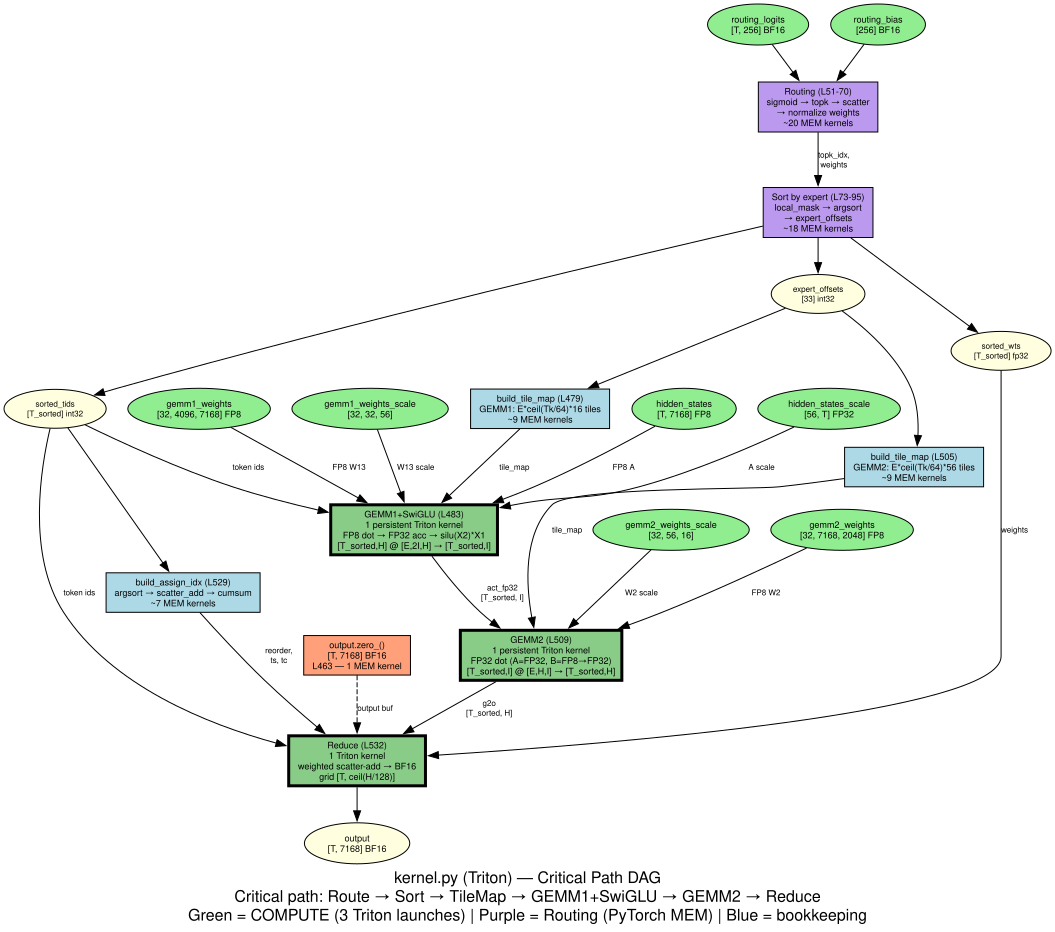

In [43]:
import graphviz
from IPython.display import display

# ═══════════════════════════════════════════════════════════════
# Critical-path DAG for kernel.py (Triton path) with data flow
# ═══════════════════════════════════════════════════════════════
# Color legend:
#   lightgreen  = input tensors
#   lightyellow = output tensors
#   lightsalmon = MEM-bound ops (PyTorch routing, tile map, assign)
#   #88CC88     = COMPUTE-bound ops (Triton fused kernels)
#   #BB99EE     = routing (PyTorch, MEM-bound, many small kernels)
#   lightblue   = GPU bookkeeping (tile maps, assign index)

cp = graphviz.Digraph("kernel_py_critical_path", format="svg")
cp.attr(rankdir="TB",
        label="kernel.py (Triton) — Critical Path DAG",
        fontsize="16", fontname="Helvetica",
        nodesep="0.3", ranksep="0.5")
cp.attr("node", fontsize="9", fontname="Helvetica")
cp.attr("edge", fontsize="8", fontname="Helvetica")

# ── Input tensors ──
cp.node("hs",   "hidden_states\n[T, 7168] FP8",           shape="ellipse", style="filled", fillcolor="lightgreen")
cp.node("hs_s", "hidden_states_scale\n[56, T] FP32",      shape="ellipse", style="filled", fillcolor="lightgreen")
cp.node("w13",  "gemm1_weights\n[32, 4096, 7168] FP8",    shape="ellipse", style="filled", fillcolor="lightgreen")
cp.node("w13s", "gemm1_weights_scale\n[32, 32, 56]",      shape="ellipse", style="filled", fillcolor="lightgreen")
cp.node("w2",   "gemm2_weights\n[32, 7168, 2048] FP8",    shape="ellipse", style="filled", fillcolor="lightgreen")
cp.node("w2s",  "gemm2_weights_scale\n[32, 56, 16]",      shape="ellipse", style="filled", fillcolor="lightgreen")
cp.node("rl",   "routing_logits\n[T, 256] BF16",          shape="ellipse", style="filled", fillcolor="lightgreen")
cp.node("rb",   "routing_bias\n[256] BF16",               shape="ellipse", style="filled", fillcolor="lightgreen")

# ── Routing (L51-70): PyTorch ops, MEM-bound ──
cp.node("route", "Routing (L51-70)\nsigmoid → topk → scatter\n→ normalize weights\n~20 MEM kernels",
        shape="box", style="filled", fillcolor="#BB99EE")

# ── Sort + expert offsets (L73-95): extra ops for Triton ──
cp.node("sort", "Sort by expert (L73-95)\nlocal_mask → argsort\n→ expert_offsets\n~18 MEM kernels",
        shape="box", style="filled", fillcolor="#BB99EE")

# ── Sorted arrays ──
cp.node("stids", "sorted_tids\n[T_sorted] int32",  shape="ellipse", style="filled", fillcolor="lightyellow", fontsize="8")
cp.node("swts",  "sorted_wts\n[T_sorted] fp32",    shape="ellipse", style="filled", fillcolor="lightyellow", fontsize="8")
cp.node("eoffs", "expert_offsets\n[33] int32",      shape="ellipse", style="filled", fillcolor="lightyellow", fontsize="8")

# ── output.zero_() ──
cp.node("zero", "output.zero_()\n[T, 7168] BF16\nL463 — 1 MEM kernel",
        shape="box", style="filled", fillcolor="lightsalmon")

# ── Build tile map GEMM1 (L479) ──
cp.node("tm1", "build_tile_map (L479)\nGEMM1: E*ceil(Tk/64)*16 tiles\n~9 MEM kernels",
        shape="box", style="filled", fillcolor="lightblue")

# ── GEMM1+SwiGLU Triton kernel (L483) ──
cp.node("gemm1", "GEMM1+SwiGLU (L483)\n1 persistent Triton kernel\nFP8 dot → FP32 acc → silu(X2)*X1\n[T_sorted,H] @ [E,2I,H] → [T_sorted,I]",
        shape="box", style="filled", fillcolor="#88CC88", penwidth="3")

# ── Build tile map GEMM2 (L505) ──
cp.node("tm2", "build_tile_map (L505)\nGEMM2: E*ceil(Tk/64)*56 tiles\n~9 MEM kernels",
        shape="box", style="filled", fillcolor="lightblue")

# ── GEMM2 Triton kernel (L509) ──
cp.node("gemm2", "GEMM2 (L509)\n1 persistent Triton kernel\nFP32 dot (A=FP32, B=FP8→FP32)\n[T_sorted,I] @ [E,H,I] → [T_sorted,H]",
        shape="box", style="filled", fillcolor="#88CC88", penwidth="3")

# ── Build assign index (L529) ──
cp.node("assign", "build_assign_idx (L529)\nargsort → scatter_add → cumsum\n~7 MEM kernels",
        shape="box", style="filled", fillcolor="lightblue")

# ── Reduce Triton kernel (L532) ──
cp.node("reduce", "Reduce (L532)\n1 Triton kernel\nweighted scatter-add → BF16\ngrid [T, ceil(H/128)]",
        shape="box", style="filled", fillcolor="#88CC88", penwidth="3")

# ── Output ──
cp.node("out", "output\n[T, 7168] BF16", shape="ellipse", style="filled", fillcolor="lightyellow")

# ── Edges: data dependencies ──
# Routing inputs
cp.edge("rl", "route")
cp.edge("rb", "route")

# Route → sort
cp.edge("route", "sort", label="topk_idx,\nweights")

# Sort outputs
cp.edge("sort", "stids")
cp.edge("sort", "swts")
cp.edge("sort", "eoffs")

# output.zero_() (independent of routing, can overlap)
cp.edge("zero", "reduce", style="dashed", label="output buf")

# Tile map GEMM1 depends on expert_offsets
cp.edge("eoffs", "tm1")

# GEMM1+SwiGLU: reads FP8 hidden, weights, scales + sorted_ids from routing
cp.edge("tm1",  "gemm1", label="tile_map")
cp.edge("hs",   "gemm1", label="FP8 A")
cp.edge("hs_s", "gemm1", label="A scale")
cp.edge("w13",  "gemm1", label="FP8 W13")
cp.edge("w13s", "gemm1", label="W13 scale")
cp.edge("stids","gemm1", label="token ids")

# Tile map GEMM2 depends on expert_offsets
cp.edge("eoffs", "tm2")

# GEMM2: reads FP32 act (from GEMM1) + FP8 W2 + scales
cp.edge("tm2",   "gemm2", label="tile_map")
cp.edge("gemm1", "gemm2", label="act_fp32\n[T_sorted, I]")
cp.edge("w2",    "gemm2", label="FP8 W2")
cp.edge("w2s",   "gemm2", label="W2 scale")

# Assign index depends on sorted_tids
cp.edge("stids", "assign")

# Reduce: reads GEMM2 output + sorted weights + assign index
cp.edge("gemm2",  "reduce", label="g2o\n[T_sorted, H]")
cp.edge("swts",   "reduce", label="weights")
cp.edge("stids",  "reduce", label="token ids")
cp.edge("assign", "reduce", label="reorder,\nts, tc")

# Final output
cp.edge("reduce", "out")

# ── Critical path annotation ──
# The critical path is: route → sort → tm1 → GEMM1 → tm2* → GEMM2 → reduce
# (* tm2 can start as soon as eoffs available, overlaps with GEMM1 in theory,
#   but is sequential in practice since build_tile_map_gpu is synchronous)
cp.attr(label="kernel.py (Triton) — Critical Path DAG\n"
              "Critical path: Route → Sort → TileMap → GEMM1+SwiGLU → GEMM2 → Reduce\n"
              "Green = COMPUTE (3 Triton launches) | Purple = Routing (PyTorch MEM) | Blue = bookkeeping")

display(cp)